# Chapter 3 — Causal Machine Learning  
## Heterogeneous Effects, Meta-Learners, and Double Machine Learning

**Course:** Causal Intelligence  
**Instructor:** Prof. Reza Arghandeh, Western Norway University of Applied Sciences, Norway  
**Year:** 2026

---

## Main purpose

This chapter introduces **causal machine learning** as a practical framework for estimating causal effects when relationships are nonlinear, high-dimensional, and heterogeneous across individuals or units.

Chapters 1 and 2 introduced association, intervention, counterfactual reasoning, causal graphs, confounding, mediation, collider bias, adjustment, and causal discovery. This chapter moves from causal reasoning and graph-based design to **effect estimation with machine learning**.

The central message is:

> Machine learning can improve causal effect estimation, but only when it is embedded inside a causal design with a clearly defined treatment, outcome, estimand, adjustment set, and assumptions.

We use one simulated healthcare example throughout the chapter. The setting is a hospital evaluating whether a treatment improves patient recovery. The dataset includes confounding, a continuous recovery score, and known heterogeneous treatment effects. This allows us to compare naive estimates, adjusted models, meta-learners, Double Machine Learning, and optional package-based implementations in a controlled setting.


## Chapter structure

1. Why causal machine learning?
2. Running example: treatment, severity, and recovery score
3. The fundamental problem of causal inference
4. Potential outcomes and treatment-effect estimands
5. Why ordinary machine learning is not enough
6. Baseline estimators: naive comparison and adjusted outcome modeling
7. Meta-learners: S-learner, T-learner, and X-learner
8. Heterogeneous treatment effects and CATE visualization
9. Double Machine Learning: orthogonalization and sample splitting
10. Optional EconML demonstration
11. Method comparison and interpretation
12. Practical checklist for causal ML projects
13. Chapter summary


</br>

---
## 1. Why Causal Machine Learning?

Ordinary machine learning is designed mainly for prediction. Given features $X$, a predictive model learns a function such as:

$$\hat{f}(X) \approx E[Y \mid X]$$

This is useful when the goal is to forecast an outcome for new observations that are similar to the training data. For example, a model may predict whether a patient is likely to recover based on age, severity, biomarkers, and treatment history.

However, many scientific and decision-making questions are not only about prediction. They are about **actions**. We often want to know what would happen if we changed a treatment, policy, process, or decision rule.

A causal question has a different form:

$$E[Y \mid do(T = 1)] - E[Y \mid do(T = 0)]$$

Here, $T$ represents a treatment, intervention, policy, or action. The expression asks:

> *What would happen to the outcome if we actively assigned treatment, compared with if we actively assigned no treatment?*

This is different from the observational comparison:

$$E[Y \mid T = 1] - E[Y \mid T = 0]$$

The observational comparison only compares units that happened to receive different treatments. If treatment assignment was not random, these groups may differ before treatment. For example, sicker patients may be more likely to receive treatment. In that case, the observed difference may mix the effect of treatment with baseline differences between patients.

Causal machine learning combines two complementary ideas:

1. **Causal inference:** defines the causal question, treatment, outcome, assumptions, and adjustment strategy.
2. **Machine learning:** flexibly estimates complex relationships, high-dimensional adjustment functions, and heterogeneous treatment effects.

The goal is not to replace causal assumptions with machine learning. A flexible model cannot remove confounding by itself, and high predictive accuracy does not guarantee a valid causal effect estimate. Instead, the goal is to place machine learning inside a causal design.

In this chapter, machine learning is useful for three main tasks:

- estimating outcome models such as $E[Y \mid T, X]$,
- estimating treatment assignment models such as $P(T = 1 \mid X)$,
- estimating how treatment effects vary across individuals or subgroups.

This last point is especially important. In many applications, the average treatment effect is not enough. A treatment may be beneficial on average but more effective for some patients than others. A demand-response policy may reduce electricity consumption for some households but have little effect for others.

This chapter focuses on **causal effect estimation**, with special attention to **heterogeneous treatment effects**. We first introduce potential outcomes and treatment-effect concepts, then study meta-learners, and finally introduce the intuition behind Double Machine Learning.


## Notebook setup: libraries and visual style

The core demonstrations use standard Python libraries so that the notebook can run in Google Colab without heavy installation requirements. Optional EconML code is included later. If EconML is not installed, the notebook will still run and will show installation instructions.


In [666]:
# Basic imports used throughout the chapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Harmonized visual style for the chapter
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
})

COLORS = {
    "navy": "#1f4e79",
    "orange": "#f28e2b",
    "green": "#59a14f",
    "red": "#e15759",
    "gray": "#7f7f7f",
    "light_blue": "#d8e8f5",
    "light_orange": "#fde6c8",
    "light_green": "#d9ead3",
    "light_red": "#f4cccc",
}

def clean_axis(ax):
    """Apply a consistent, minimal style to matplotlib axes."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    return ax

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def draw_dag(edges, pos=None, title="Causal graph", node_colors=None, figsize=(8, 5)):
    """Draw a directed graph with consistent style."""
    G = nx.DiGraph()
    G.add_edges_from(edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    node_colors = node_colors or {node: COLORS["light_blue"] for node in G.nodes()}
    colors = [node_colors.get(node, COLORS["light_blue"]) for node in G.nodes()]
    plt.figure(figsize=figsize)
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=3000,
        node_color=colors,
        edgecolors=COLORS["navy"],
        arrows=True,
        arrowsize=18,
        font_size=9,
        font_weight="bold",
        width=1.8,
    )
    plt.title(title)
    plt.axis("off")
    plt.show()
    return G


</br>

---
## 2. Running example: treatment, severity, and recovery score

We use one simulated healthcare dataset throughout the chapter.

The hospital wants to evaluate whether a treatment improves patient recovery. Treatment is not randomly assigned. More severe patients and patients with worse biomarker values are more likely to receive treatment, which creates confounding.

The variables are:

| Variable | Meaning | Role in this chapter |
|---|---|---|
| `Age` | Patient age | Pre-treatment covariate |
| `Socioeconomic` | Socioeconomic status proxy | Pre-treatment covariate |
| `Severity` | Baseline disease severity | Confounder and effect modifier |
| `Biomarker` | Clinical biomarker before treatment | Confounder and effect modifier |
| `Treatment` | Whether the patient receives treatment | Treatment/intervention |
| `Inflammation` | Post-treatment biological response | Mediator; not used for total-effect adjustment |
| `RecoveryScore` | Continuous recovery score | Main outcome for causal ML |
| `Recovery` | Binary recovery indicator | Auxiliary outcome |
| `TrueTreatmentEffect` | Known simulated individual treatment effect | Used only for teaching/evaluation |

The main causal question is:

$$E[RecoveryScore \mid do(Treatment=1)] - E[RecoveryScore \mid do(Treatment=0)]$$

This asks whether assigning treatment would improve the average recovery score in the patient population.

The heterogeneity question is:

$$E[RecoveryScore(1) - RecoveryScore(0) \mid X=x]$$

where $X$ contains pre-treatment patient characteristics. This asks whether the treatment effect differs across patients with different age, severity, socioeconomic status, or biomarker profiles.

The next code cell simulates this dataset. Because it is a simulation, we generate both potential outcomes for each patient:

- `Y0`: the recovery score under no treatment,
- `Y1`: the recovery score under treatment.

In real observational data, we would observe only one of these outcomes for each patient. Here, we keep both potential outcomes only for teaching and evaluation. This allows us to compare causal machine learning estimates against the known simulated treatment effect.


In [667]:
def simulate_healthcare_causal_ml_data(n=3000, seed=42):
    """Simulate a healthcare dataset for causal ML teaching.

    The data include confounding and heterogeneous treatment effects.
    Treatment is assigned observationally, not randomly.
    The true potential outcomes are known because this is a simulation.
    """
    rng = np.random.default_rng(seed)

    # Background variables
    age = rng.normal(55, 12, n)
    age_std = (age - 55) / 12
    socioeconomic = rng.normal(0, 1, n)

    # Pre-treatment health variables
    severity = 0.45 * age_std - 0.55 * socioeconomic + rng.normal(0, 1, n)
    biomarker = 0.85 * severity + 0.20 * age_std + rng.normal(0, 0.8, n)

    # Observational treatment assignment:
    # sicker patients and patients with worse biomarkers are more likely to receive treatment.
    p_treat = sigmoid(-0.30 + 0.95 * severity + 0.45 * biomarker - 0.15 * socioeconomic)
    treatment = rng.binomial(1, p_treat, n)

    # Heterogeneous treatment effect:
    # treatment helps most for higher-severity patients, but less for older patients.
    true_tau = (
        4.5
        + 3.0 * sigmoid(severity)
        + 1.2 * (biomarker > np.median(biomarker)).astype(float)
        - 0.8 * age_std
    )
    true_tau = np.clip(true_tau, 1.0, 10.0)

    # Potential outcomes for a continuous recovery score.
    # Higher recovery score is better.
    baseline_noise = rng.normal(0, 4.0, n)
    y0 = 72 - 7.5 * severity + 2.0 * socioeconomic - 1.2 * age_std + baseline_noise
    y1 = y0 + true_tau

    # Observed outcome under the treatment actually received.
    recovery_score = np.where(treatment == 1, y1, y0)

    # Mediator generated after treatment; included to connect with Chapter 2,
    # but not used for total-effect adjustment.
    inflammation = 1.10 * severity - 0.75 * treatment + rng.normal(0, 0.9, n)

    # Binary recovery indicator as an auxiliary outcome.
    p_recovery = sigmoid((recovery_score - 70) / 8)
    recovery = rng.binomial(1, p_recovery, n)

    return pd.DataFrame({
        "Age": age,
        "Socioeconomic": socioeconomic,
        "Severity": severity,
        "Biomarker": biomarker,
        "Treatment": treatment,
        "Inflammation": inflammation,
        "RecoveryScore": recovery_score,
        "Recovery": recovery,
        "Propensity": p_treat,
        "Y0": y0,
        "Y1": y1,
        "TrueTreatmentEffect": true_tau,
    })

health = simulate_healthcare_causal_ml_data()
health.head()


,Age,Socioeconomic,Severity,Biomarker,Treatment,Inflammation,RecoveryScore,Recovery,Propensity,Y0,Y1,TrueTreatmentEffect
0,58.656605,1.249023,-0.324723,-0.132452,0,0.301883,73.402845,1,0.298292,73.402845,78.917646,5.514802
1,42.520191,0.687692,-0.899567,-1.867151,0,-1.567240,85.229287,1,0.109295,85.229287,91.428693,6.199406
2,64.005414,1.966127,0.120377,0.333036,0,-0.083613,78.178072,1,0.418071,78.178072,84.867885,6.689813
3,66.286777,-1.547833,1.881295,0.870464,1,1.279177,62.542332,0,0.891979,54.991504,62.542332,7.550828
4,31.587578,-0.265360,-3.717840,-2.600875,0,-2.610224,99.244738,1,0.006947,99.244738,105.376698,6.131960


</br>

The code below summarizes the simulated dataset by treatment group.

This table helps us inspect whether the treated and untreated groups are comparable. If treated patients have higher severity or worse biomarker values, then a simple comparison of recovery outcomes may be confounded. The column `mean_true_effect` is available only because this is a simulation; it shows whether the patients who received treatment also tend to have different underlying treatment benefits.

In [668]:
summary = health.groupby("Treatment").agg(
    patients=("RecoveryScore", "size"),
    mean_severity=("Severity", "mean"),
    mean_biomarker=("Biomarker", "mean"),
    mean_recovery_score=("RecoveryScore", "mean"),
    recovery_rate=("Recovery", "mean"),
    mean_true_effect=("TrueTreatmentEffect", "mean"),
)
summary.round(3)


,patients,mean_severity,mean_biomarker,mean_recovery_score,recovery_rate,mean_true_effect
Treatment,,,,,,
0,1667,-0.644,-0.705,77.732,0.696,6.152
1,1333,0.760,0.785,72.733,0.563,7.177


</br>

The code below visualizes the main differences between treated and untreated patients.

Together, these plots show why the raw outcome comparison should not be interpreted causally. If treated patients are more severe at baseline, their observed recovery scores may reflect both the treatment effect and pre-existing health differences.

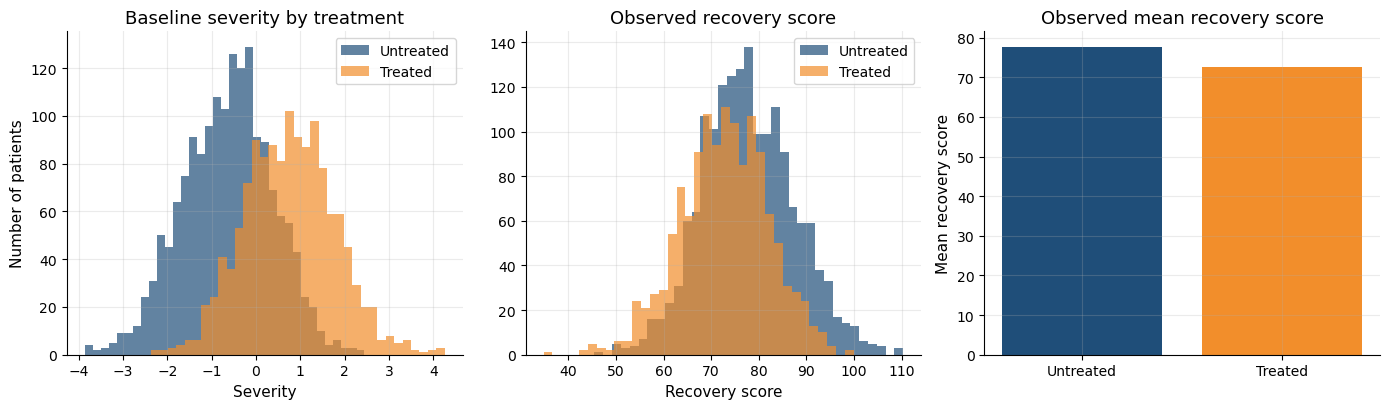

In [669]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].hist(
    health.loc[health["Treatment"] == 0, "Severity"],
    bins=35, alpha=0.70, label="Untreated", color=COLORS["navy"]
)
axes[0].hist(
    health.loc[health["Treatment"] == 1, "Severity"],
    bins=35, alpha=0.70, label="Treated", color=COLORS["orange"]
)
axes[0].set_title("Baseline severity by treatment")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Number of patients")
axes[0].legend()
clean_axis(axes[0])

axes[1].hist(
    health.loc[health["Treatment"] == 0, "RecoveryScore"],
    bins=35, alpha=0.70, label="Untreated", color=COLORS["navy"]
)
axes[1].hist(
    health.loc[health["Treatment"] == 1, "RecoveryScore"],
    bins=35, alpha=0.70, label="Treated", color=COLORS["orange"]
)
axes[1].set_title("Observed recovery score")
axes[1].set_xlabel("Recovery score")
axes[1].legend()
clean_axis(axes[1])

rates = health.groupby("Treatment")["RecoveryScore"].mean()
axes[2].bar(["Untreated", "Treated"], rates.values, color=[COLORS["navy"], COLORS["orange"]])
axes[2].set_title("Observed mean recovery score")
axes[2].set_ylabel("Mean recovery score")
clean_axis(axes[2])

plt.tight_layout()
plt.show()


### Interpretation

The plots show that the treated and untreated groups are not directly comparable.

- The first plot shows that treated patients have higher baseline severity on average. This reflects the observational treatment assignment process: patients with more serious conditions are more likely to receive treatment.

- The second plot shows the observed recovery score distributions. The treated group has slightly lower recovery scores in the observed data, but this does not necessarily mean that the treatment is harmful. The treated patients started from a worse baseline condition.

- The third plot summarizes this pattern using the mean recovery score. The untreated group has a higher observed average recovery score than the treated group. A naive comparison would therefore suggest a negative treatment effect.

However, this comparison mixes two different quantities:

1. the possible causal effect of treatment, and  
2. baseline differences between patients who did and did not receive treatment.

Because treatment assignment depends on pre-treatment variables such as severity and biomarker values, the raw difference in recovery scores is an associational comparison:

$$E[RecoveryScore \mid Treatment=1] - E[RecoveryScore \mid Treatment=0]$$

It should not be interpreted as the causal effect:

$$E[RecoveryScore \mid do(Treatment=1)] - E[RecoveryScore \mid do(Treatment=0)]$$


> The main lesson is that causal machine learning must first address the causal design problem: which variables should be adjusted for, and which estimand are we trying to estimate? Only after this step can machine learning be used responsibly to estimate average or heterogeneous treatment effects.


---
### Causal structure of the running example

The DAG summarizes the assumed causal structure behind the simulated healthcare dataset. The main causal question is whether `Treatment` improves `RecoveryScore`.

The graph shows that treatment is not randomly assigned. Pre-treatment variables such as `Age`, `Socioeconomic`, `Severity`, and `Biomarker` influence which patients receive treatment. Some of these variables also affect recovery. Therefore, a simple comparison between treated and untreated patients may be confounded.

Several important paths are visible in the graph. The direct causal effect of interest is:

$$Treatment \rightarrow RecoveryScore$$

There is also an indirect pathway through the post-treatment mediator:

$$Treatment \rightarrow Inflammation \rightarrow RecoveryScore$$

At the same time, there are backdoor paths from treatment to recovery, such as:

$$Treatment \leftarrow Severity \rightarrow RecoveryScore$$

and:

$$Treatment \leftarrow Biomarker \leftarrow Severity \rightarrow RecoveryScore$$

These backdoor paths explain why the observed difference between treated and untreated patients should not be interpreted directly as a causal effect. To estimate the total effect of treatment, we should adjust for appropriate pre-treatment variables, such as `Age`, `Socioeconomic`, `Severity`, and `Biomarker`. We should not adjust for `Inflammation` when estimating the total effect, because it is generated after treatment and lies on part of the causal pathway from treatment to recovery.

**Node colors in the graph**:

The node colors are used only as visual teaching aids:

- Light blue nodes indicate background pre-treatment variables: `Age` and `Socioeconomic`.
- Light orange nodes indicate pre-treatment health variables: `Severity` and `Biomarker`. These variables are important because they may act as confounders and effect modifiers.
- Light green nodes indicate the main treatment-outcome pair: `Treatment` and `RecoveryScore`.
- Light red indicates the post-treatment mediator: `Inflammation`.

The colors do not represent statistical significance, causal strength, or confidence in the edges. They are used only to make the causal roles of the variables easier to read.

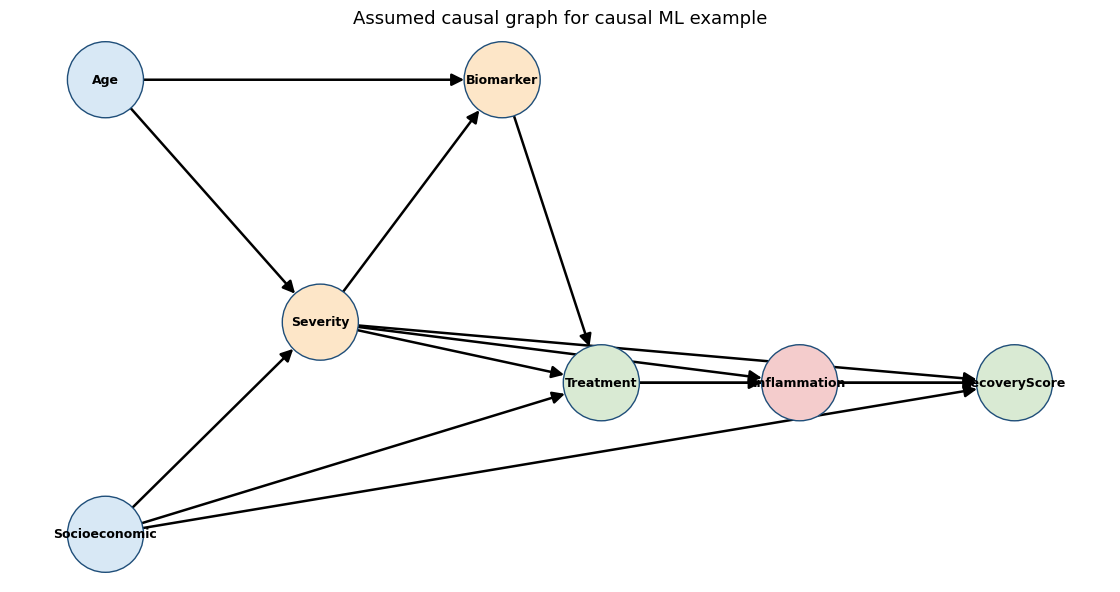

In [670]:
edges = [
    ("Age", "Severity"),
    ("Age", "Biomarker"),
    ("Socioeconomic", "Severity"),
    ("Socioeconomic", "Treatment"),
    ("Socioeconomic", "RecoveryScore"),
    ("Severity", "Biomarker"),
    ("Severity", "Treatment"),
    ("Biomarker", "Treatment"),
    ("Severity", "RecoveryScore"),
    ("Treatment", "RecoveryScore"),
    ("Treatment", "Inflammation"),
    ("Severity", "Inflammation"),
    ("Inflammation", "RecoveryScore"),
]

pos = {
    "Age": (-2.5, 1.2),
    "Socioeconomic": (-2.5, -0.3),
    "Severity": (-1.2, 0.4),
    "Biomarker": (-0.1, 1.2),
    "Treatment": (0.5, 0.2),
    "Inflammation": (1.7, 0.2),
    "RecoveryScore": (3.0, 0.2),
}

node_colors = {
    "Age": COLORS["light_blue"],
    "Socioeconomic": COLORS["light_blue"],
    "Severity": COLORS["light_orange"],
    "Biomarker": COLORS["light_orange"],
    "Treatment": COLORS["light_green"],
    "Inflammation": COLORS["light_red"],
    "RecoveryScore": COLORS["light_green"],
}

draw_dag(edges, pos=pos, title="Assumed causal graph for causal ML example", node_colors=node_colors, figsize=(11, 5.5));


</br>

---
## 3. The Fundamental Problem of Causal Inference

Causal inference is difficult because, for each individual patient, there are two potential outcomes but only one can be observed.

For patient $i$, define:

$$Y_i(1)$$

as the recovery score if patient $i$ receives treatment, and:

$$Y_i(0)$$

as the recovery score if patient $i$ does not receive treatment.

The individual treatment effect is:

$$\tau_i = Y_i(1) - Y_i(0)$$

This quantity compares two possible outcomes for the same patient. However, in real data we cannot observe both outcomes at the same time. A patient either receives treatment or does not receive treatment.

The observed outcome is:

$$Y_i = T_iY_i(1) + (1 - T_i)Y_i(0)$$

where $T_i = 1$ means that patient $i$ received treatment, and $T_i = 0$ means that patient $i$ did not receive treatment.

Therefore:

- if $T_i = 1$, we observe $Y_i(1)$ but not $Y_i(0)$;
- if $T_i = 0$, we observe $Y_i(0)$ but not $Y_i(1)$.

The missing outcome is the **counterfactual outcome**: what would have happened to the same patient under the treatment condition they did not actually receive.

This is the **fundamental problem of causal inference**:

> For each individual, we observe only one potential outcome, while the other potential outcome is missing.

This is why **causal effect estimation cannot be reduced to ordinary prediction**. In prediction, we try to estimate the observed outcome. In causal inference, we try to reason about outcomes under alternative interventions, including outcomes that were not observed for each individual.

Causal machine learning addresses this problem by combining:

- causal assumptions about treatment assignment and confounding,
- appropriate adjustment using pre-treatment variables,
- flexible machine learning models for outcome and treatment assignment functions,
- estimation of average and heterogeneous treatment effects.

The next code cell illustrates the fundamental problem using the simulated dataset. Because this is a simulation, we have access to both $Y_i(0)$ and $Y_i(1)$ for teaching purposes. The code shows, for a small sample of patients, which potential outcome is observed and which one is missing as the counterfactual. In real observational data, the columns `Y0`, `Y1`, and `TrueTreatmentEffect` would not be directly available.


In [671]:
# Show the potential-outcome structure for a small sample.
example_po = health[["Treatment", "RecoveryScore", "Y0", "Y1", "TrueTreatmentEffect"]].head(8).copy()
example_po["Observed potential outcome"] = np.where(example_po["Treatment"] == 1, "Y(1)", "Y(0)")
example_po["Missing counterfactual"] = np.where(example_po["Treatment"] == 1, "Y(0)", "Y(1)")
example_po.round(2)


,Treatment,RecoveryScore,Y0,Y1,TrueTreatmentEffect,Observed potential outcome,Missing counterfactual
0,0,73.40,73.40,78.92,5.51,Y(0),Y(1)
1,0,85.23,85.23,91.43,6.20,Y(0),Y(1)
2,0,78.18,78.18,84.87,6.69,Y(0),Y(1)
3,1,62.54,54.99,62.54,7.55,Y(1),Y(0)
4,0,99.24,99.24,105.38,6.13,Y(0),Y(1)
5,0,69.20,69.20,77.60,8.40,Y(0),Y(1)
6,1,75.19,67.99,75.19,7.20,Y(1),Y(0)
7,0,85.36,85.36,90.42,5.07,Y(0),Y(1)


### Interpretation

The table shows the logic of potential outcomes. The simulation stores both $Y(0)$ and $Y(1)$, but a real dataset would only contain the observed outcome. The unobserved potential outcome is the missing counterfactual.

This is why treatment-effect estimation cannot be reduced to ordinary prediction. We are trying to learn about outcomes under interventions that are not fully observed for each unit.


</br>

---
## 4. Treatment Effect Estimands

Before choosing a causal machine learning method, we need to define the **estimand**.

An estimand is the causal quantity we want to estimate. This is different from an estimator, which is the method or algorithm used to estimate that quantity from data.

In this chapter, the treatment is `Treatment` and the main outcome is `RecoveryScore`. Because the simulated dataset contains potential outcomes, we can define several treatment-effect quantities exactly.

For each patient $i$, the individual treatment effect is:

$$\tau_i = Y_i(1) - Y_i(0)$$

However, in real data, $\tau_i$ is not directly observed because we do not observe both $Y_i(1)$ and $Y_i(0)$ for the same patient.

Instead, causal inference often focuses on population-level or subgroup-level summaries.


---
### 4.1 Average Treatment Effect (ATE)

The **Average Treatment Effect** measures the average causal effect of treatment in the full population:

$$ATE = E[Y(1) - Y(0)]$$

In this example, it answers the question:

> By how much would the average recovery score change if all patients received treatment instead of no treatment?

Because this is a simulation, the next code cell computes the true ATE directly from the simulated potential outcomes `Y1` and `Y0`. In real observational data, this direct calculation would not be possible.

In [672]:
true_ate = (health["Y1"] - health["Y0"]).mean()

print(f"True ATE: {true_ate:.3f}")

True ATE: 6.608


---
### 4.2 Average Treatment Effect on the Treated (ATT)

The **Average Treatment Effect on the Treated** measures the average causal effect among patients who actually received treatment:

$$ATT = E[Y(1) - Y(0) \mid T = 1]$$

This estimand answers:

> Among patients who received treatment, how much did treatment improve their recovery score on average?

The ATT can differ from the ATE when treatment effects are heterogeneous and when treated patients differ systematically from untreated patients. In our simulated dataset, more severe patients are more likely to receive treatment, and severity also modifies the treatment effect.

The next code cell computes the true ATT using the simulated individual treatment effects.

In [673]:
true_att = (
    health.loc[health["Treatment"] == 1, "Y1"]
    - health.loc[health["Treatment"] == 1, "Y0"]
).mean()

print(f"True ATT: {true_att:.3f}")

True ATT: 7.177


---
### 4.3 Average Treatment Effect on the Untreated (ATU)

The **Average Treatment Effect on the Untreated** measures the average causal effect among patients who did not receive treatment:

$$ATU = E[Y(1) - Y(0) \mid T = 0]$$

This estimand answers:

> Among patients who did not receive treatment, how much would their recovery score have changed if they had received treatment?

The ATU is useful when we want to evaluate whether expanding treatment to currently untreated patients would be beneficial.

The next code cell computes the true ATU from the simulated potential outcomes.

In [674]:
true_atu = (
    health.loc[health["Treatment"] == 0, "Y1"]
    - health.loc[health["Treatment"] == 0, "Y0"]
).mean()

print(f"True ATU: {true_atu:.3f}")

True ATU: 6.152


---
### 4.4 Conditional Average Treatment Effect (CATE)

The **Conditional Average Treatment Effect** measures how the treatment effect varies across patient characteristics:

$$CATE(x) = E[Y(1) - Y(0) \mid X = x]$$

Here, $X$ represents pre-treatment covariates such as `Age`, `Severity`, `Biomarker`, and `Socioeconomic`.

This estimand answers:

> Which types of patients benefit more or less from treatment?

CATE is central to causal machine learning because machine learning can help estimate treatment-effect heterogeneity in flexible ways.

In the simulation, we know the true individual treatment effect. The next code cell summarizes how the true treatment effect varies by severity group.

In [675]:
health["SeverityGroup"] = pd.qcut(
    health["Severity"],
    q=4,
    labels=["Low severity", "Medium-low", "Medium-high", "High severity"]
)

cate_by_severity = health.groupby("SeverityGroup", observed=True).agg(
    patients=("RecoveryScore", "size"),
    mean_severity=("Severity", "mean"),
    mean_true_effect=("TrueTreatmentEffect", "mean")
)

cate_by_severity.round(3)

,patients,mean_severity,mean_true_effect
SeverityGroup,,,
Low severity,750,-1.585,5.534
Medium-low,750,-0.419,6.209
Medium-high,750,0.370,6.998
High severity,750,1.554,7.690


The table above shows whether the simulated treatment effect differs across severity groups. Since the data-generating process was designed so that treatment helps more for higher-severity patients, we expect the average true treatment effect to increase with severity.

The next code cell visualizes this heterogeneity. This type of plot is useful because it moves beyond the single average treatment effect and shows how the expected benefit changes across clinically meaningful groups.

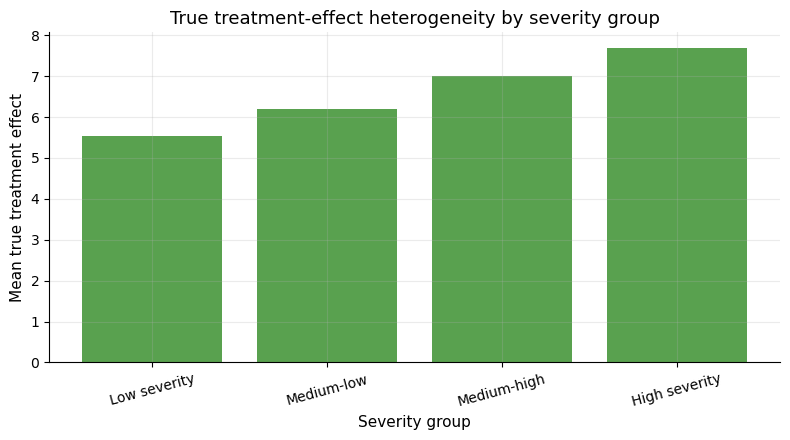

In [676]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    cate_by_severity.index.astype(str),
    cate_by_severity["mean_true_effect"],
    color=COLORS["green"]
)

ax.set_title("True treatment-effect heterogeneity by severity group")
ax.set_xlabel("Severity group")
ax.set_ylabel("Mean true treatment effect")
clean_axis(ax)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
### 4.5 Why estimands matter

Different causal questions require different estimands.

| Estimand | Mathematical form | Question |
|---|---|---|
| ATE | $E[Y(1) - Y(0)]$ | What is the average effect in the full population? |
| ATT | $E[Y(1) - Y(0) \mid T=1]$ | What is the average effect among treated patients? |
| ATU | $E[Y(1) - Y(0) \mid T=0]$ | What would be the average effect among untreated patients if treated? |
| CATE | $E[Y(1) - Y(0) \mid X=x]$ | How does the effect vary by patient characteristics? |

The estimand should be chosen before fitting a model. Otherwise, we may estimate a quantity that does not match the scientific or decision-making question.

For example:

- If the hospital wants to know whether the treatment works overall, the ATE may be appropriate.
- If the hospital wants to evaluate whether treated patients benefited, the ATT may be more relevant.
- If the hospital wants to decide whether to expand treatment to untreated patients, the ATU may be useful.
- If the hospital wants to personalize treatment decisions, the CATE is the main target.

Causal machine learning is especially useful for estimating CATE and related heterogeneous treatment effects, but these estimates are meaningful only when the causal question, treatment, outcome, and assumptions are clearly defined.

### How to interpret numerical values of ATE, ATT, ATU, and CATE

Treatment-effect values are interpreted in the **unit of the outcome variable**.

In this chapter, the outcome is `RecoveryScore`, where higher values mean better recovery. Therefore, a positive value means that treatment improves recovery, while a negative value means that treatment reduces recovery.

| Estimand | Mathematical form | What the number means | Example if value is positive | Example if value is negative |
|---|---|---|---|---|
| ATE | $E[Y(1) - Y(0)]$ | Average treatment effect in the full population | $ATE = 6$ means treatment increases the average recovery score by 6 points for the full population | $ATE = -6$ means treatment decreases the average recovery score by 6 points for the full population |
| ATT | $E[Y(1) - Y(0) \mid T=1]$ | Average treatment effect among patients who actually received treatment | $ATT = 7$ means treated patients gained 7 recovery-score points on average because of treatment | $ATT = -7$ means treated patients lost 7 recovery-score points on average because of treatment |
| ATU | $E[Y(1) - Y(0) \mid T=0]$ | Average treatment effect among patients who did not receive treatment | $ATU = 5$ means untreated patients would gain 5 recovery-score points on average if treated | $ATU = -5$ means untreated patients would lose 5 recovery-score points on average if treated |
| CATE | $E[Y(1) - Y(0) \mid X=x]$ | Average treatment effect for a subgroup or type of patient with characteristics $X=x$ | $CATE(x)=8$ means patients with characteristics $x$ are expected to gain 8 recovery-score points from treatment | $CATE(x)=-8$ means patients with characteristics $x$ are expected to lose 8 recovery-score points from treatment |



Because all four are based on the contrast:

$$Y(1) - Y(0)$$

their sign has the same basic interpretation:

| Sign | Meaning when higher outcome is better | Meaning when lower outcome is better |
|---|---|---|
| Positive | Treatment increases the outcome; usually beneficial | Treatment increases the outcome; usually harmful |
| Zero | No average effect | No average effect |
| Negative | Treatment decreases the outcome; usually harmful | Treatment decreases the outcome; usually beneficial |

For the healthcare example in this chapter, higher `RecoveryScore` is better. Therefore, **larger positive values are better**.

However, this interpretation depends on the outcome. If the outcome were `Mortality`, `FailureRisk`, `EnergyConsumption`, or `CO2Emissions`, then lower values would be preferred. In that case, a negative treatment effect could be beneficial.

The practical rule is:

> First decide whether higher values of the outcome are desirable or undesirable. Then interpret the sign and magnitude of the treatment effect in the unit of that outcome.

</br>

---
## 5. Why Ordinary Machine Learning is Not Enough

Ordinary machine learning is powerful for prediction, but causal effect estimation asks a different question.

A predictive model usually estimates:

$$E[Y \mid T, X]$$

This means:

> What outcome do we expect for patients with treatment status $T$ and characteristics $X$?

A causal model asks:

$$E[Y \mid do(T=1)] - E[Y \mid do(T=0)]$$

This means:

> What would happen to the outcome if we actively assigned treatment, compared with if we actively assigned no treatment?

These two questions are not the same.

In observational data, treatment is not randomly assigned. Patients who receive treatment may differ systematically from patients who do not receive treatment. In our healthcare example, more severe patients are more likely to receive treatment. Therefore, treatment status contains information about both the treatment and the patient’s baseline risk.

A standard machine learning model may use `Treatment` as a predictive feature, but it does not automatically know whether treatment caused the outcome or whether treatment is simply associated with patients who were already more severe.

This creates several important problems:

1. **Prediction is not intervention**  
   A model trained to predict $Y$ from $T$ and $X$ estimates observed associations, not necessarily causal effects.

2. **Confounding can distort the treatment-outcome relationship**  
   If treatment assignment depends on severity, biomarker values, or socioeconomic status, then treated and untreated patients are not directly comparable.

3. **High predictive accuracy does not imply causal validity**  
   A model can predict recovery well while still giving a misleading estimate of the treatment effect.

4. **Regularization can bias treatment-effect estimates**  
   Flexible machine learning models often shrink, smooth, or ignore weak treatment-related signals if doing so improves prediction.

5. **Target leakage and wrong adjustment can change the estimand**  
   Post-treatment variables, such as `Inflammation`, may accidentally enter the model. If the goal is to estimate the total effect of treatment, adjusting for post-treatment mediators can remove part of the effect we want to estimate.

A further challenge is **heterogeneity**. A single average effect may hide important subgroup differences. Some patients may benefit more than others depending on severity, age, socioeconomic status, or biomarker profile.

The practical lesson is:

> A machine learning model may have low prediction error but still answer the wrong causal question.

This is why causal machine learning does not simply apply ordinary ML to causal data. It first defines the causal question, estimand, adjustment strategy, and assumptions. Then machine learning is used to estimate the necessary functions more flexibly.


---
### 5.1 A predictive machine learning model

The next code cell fits a standard random forest model to predict `RecoveryScore` using `Treatment` and pre-treatment covariates.

This model is useful for prediction. However, its purpose is to minimize prediction error, not to estimate the causal effect of assigning treatment. Therefore, good predictive performance should not be interpreted as evidence that the model has learned the correct causal effect.

In [677]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features used for prediction
predictive_features = ["Treatment", "Age", "Socioeconomic", "Severity", "Biomarker"]

X = health[predictive_features]
y = health["RecoveryScore"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

rf_predictive = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=10,
    random_state=42
)

rf_predictive.fit(X_train, y_train)

y_pred = rf_predictive.predict(X_test)

# Compatible with older and newer scikit-learn versions
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Predictive RMSE: {rmse:.3f}")
print(f"Predictive R²: {r2:.3f}")

Predictive RMSE: 4.267
Predictive R²: 0.820


The model may achieve good predictive performance. This means it can forecast observed recovery scores for patients similar to those in the training data.

However, this does not answer the causal question. The model has learned patterns in the observed data, where treatment assignment is confounded by severity and biomarker values. A good predictive score does not tell us whether the model has recovered the effect of assigning treatment by intervention.

---
### 5.2 Feature importance is not causal importance

The next code cell plots feature importances from the random forest model.

Feature importance tells us which variables were useful for prediction in this specific model. It does not tell us which variables are causes of the outcome, nor does it estimate the causal effect of treatment.

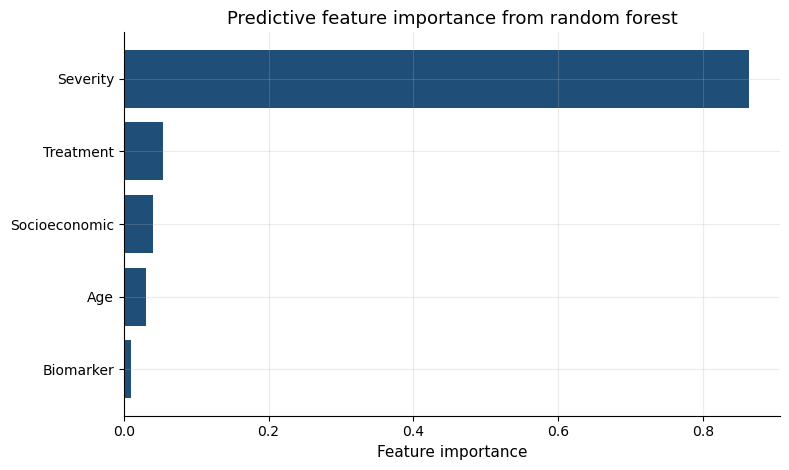

In [678]:
importances = pd.Series(
    rf_predictive.feature_importances_,
    index=predictive_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.barh(importances.index, importances.values, color=COLORS["navy"])
ax.set_title("Predictive feature importance from random forest")
ax.set_xlabel("Feature importance")
clean_axis(ax)

plt.tight_layout()
plt.show()

The plot shows which variables helped the random forest predict observed recovery scores. Variables such as `Severity` and `Biomarker` may be highly predictive because they are strongly related to patient recovery.

The importance of `Treatment` should be interpreted carefully. Since treatment is more likely to be assigned to severe patients, treatment status partly reflects baseline risk. Its predictive role may combine the treatment effect with the selection process that determined who received treatment.

The key lesson is:

> Predictive importance is not the same as causal effect.

A variable can be highly predictive without being causal. Conversely, a true causal variable may have low feature importance if its effect is subtle, heterogeneous, or partly masked by other predictors.

---
### 5.3 Naive treatment comparison from observed data

The next code cell computes the simple observed difference in mean recovery score between treated and untreated patients:

$$E[Y \mid T=1] - E[Y \mid T=0]$$

This is an associational comparison. It compares patients who happened to receive treatment with patients who happened not to receive treatment. It does not compare the same population under two interventions.

In [679]:
observed_treated_mean = health.loc[health["Treatment"] == 1, "RecoveryScore"].mean()
observed_untreated_mean = health.loc[health["Treatment"] == 0, "RecoveryScore"].mean()
naive_difference = observed_treated_mean - observed_untreated_mean

print(f"Observed mean recovery score, treated:   {observed_treated_mean:.3f}")
print(f"Observed mean recovery score, untreated: {observed_untreated_mean:.3f}")
print(f"Naive observed difference:               {naive_difference:.3f}")

Observed mean recovery score, treated:   72.733
Observed mean recovery score, untreated: 77.732
Naive observed difference:               -4.999


The naive observed difference compares two groups that are not comparable at baseline. In this simulation, treated patients are more severe on average. Therefore, the observed difference may underestimate the benefit of treatment or even suggest that treatment is harmful.

> The problem is not the arithmetic. **The problem is the causal design: the treated and untreated groups differ before treatment.**

---
### 5.4 Comparing the naive association with the true causal effect

Because this is a simulated dataset, we know the true potential outcomes. Therefore, we can compute the true Average Treatment Effect:

$$ATE = E[Y(1) - Y(0)]$$

The next code cell compares the naive observed difference with the true simulated ATE. In real observational data, the true ATE would not be directly available.

In [680]:
true_ate = (health["Y1"] - health["Y0"]).mean()

comparison = pd.DataFrame({
    "Quantity": [
        "Naive observed difference",
        "True ATE from simulated potential outcomes"
    ],
    "Value": [
        naive_difference,
        true_ate
    ]
})

comparison.round(3)

,Quantity,Value
0,Naive observed difference,-4.999
1,True ATE from simulated potential outcomes,6.608


The table compares two fundamentally different quantities.

The **naive observed difference** estimates:

$$E[Y \mid T=1] - E[Y \mid T=0]$$

The **true ATE** is:

$$E[Y(1) - Y(0)]$$

These quantities can differ substantially because the first is based on observed treatment groups, while the second is based on an intervention contrast. The simulation makes this difference visible because we know the potential outcomes by construction.

---
### 5.5 Visual comparison: association versus causation

The next code cell visualizes the difference between the naive observed comparison and the true causal effect.

This plot is useful because it shows that an ordinary comparison of observed outcomes can point in the wrong direction when treatment assignment is confounded.

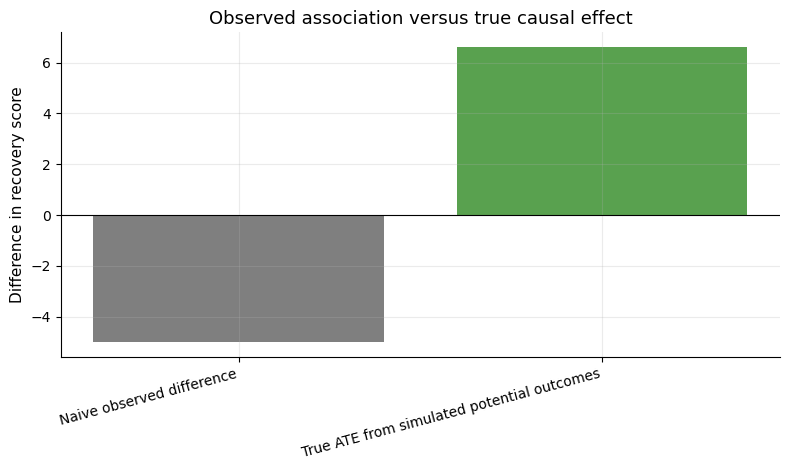

In [681]:
fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar(
    comparison["Quantity"],
    comparison["Value"],
    color=[COLORS["gray"], COLORS["green"]]
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Observed association versus true causal effect")
ax.set_ylabel("Difference in recovery score")
clean_axis(ax)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

The figure highlights the central problem. The observed association is negative, while the true causal effect is positive.

This happens because treated patients are more severe at baseline. Their lower observed recovery scores are partly due to pre-treatment severity, not necessarily due to treatment.

> This is why ordinary machine learning and naive group comparisons are not enough for causal inference. We need methods that explicitly address the treatment assignment process and compare treated and untreated outcomes among comparable patients.

---
### 5.6 Why not just use the predictive model to simulate treatment?

A common idea is to fit a predictive model and then change `Treatment` from 0 to 1 while keeping other variables fixed. This gives a model-based contrast:

$$\hat{E}[Y \mid T=1, X] - \hat{E}[Y \mid T=0, X]$$

This is closer to a causal workflow than a raw group comparison because it compares two treatment settings for the same covariate distribution. However, it is only causal if the adjustment set is appropriate, overlap is sufficient, and the model is reliable in both treatment regimes.

The next code cell uses the predictive random forest model to estimate the effect of changing treatment while keeping the pre-treatment covariates fixed.

In [682]:
X_do1 = health[predictive_features].copy()
X_do0 = health[predictive_features].copy()

X_do1["Treatment"] = 1
X_do0["Treatment"] = 0

rf_do1 = rf_predictive.predict(X_do1)
rf_do0 = rf_predictive.predict(X_do0)

rf_plugin_effect = np.mean(rf_do1 - rf_do0)

print(f"Random forest plug-in treatment-effect estimate: {rf_plugin_effect:.3f}")
print(f"True ATE:                                      {true_ate:.3f}")

Random forest plug-in treatment-effect estimate: 5.048
True ATE:                                      6.608


This plug-in estimate compares predicted outcomes under two hypothetical treatment settings. It is more informative than the raw observed difference because each patient is evaluated twice: once as treated and once as untreated.

However, this approach still has limitations. The random forest was trained as a prediction model, not as a causal estimator. It may be biased if important confounders are missing, if the model extrapolates into regions with poor overlap, or if regularization smooths away treatment-effect heterogeneity.

This motivates causal machine learning methods that are designed specifically for treatment-effect estimation.

---
### 5.7 Main lesson

Ordinary machine learning helps us predict outcomes, but causal machine learning helps us estimate what would happen under interventions.

| Task | Question | Typical target |
|---|---|---|
| Prediction | What outcome do we expect for this patient? | $E[Y \mid T, X]$ |
| Naive comparison | How do treated and untreated patients differ in the observed data? | $E[Y \mid T=1] - E[Y \mid T=0]$ |
| Causal effect estimation | What would happen if we assigned treatment? | $E[Y \mid do(T=1)] - E[Y \mid do(T=0)]$ |
| Heterogeneous effect estimation | Which patients benefit most? | $E[Y(1)-Y(0) \mid X=x]$ |

The practical message is:

> Machine learning is useful for causal inference only when it is embedded in a causal design.

This means we must first define the treatment, outcome, estimand, adjustment variables, and assumptions. Then machine learning can help estimate complex nuisance functions and heterogeneous effects.

</br>

---
## 6. Baseline Estimators: Naive Comparison and Adjusted Outcome Modeling

Section 5 showed that ordinary machine learning can predict recovery well while still answering the wrong causal question. We now introduce two simple baseline estimators for treatment effects.

These baselines are useful because they make the transition from prediction to causal estimation explicit.

We compare:

1. **Naive difference in means**  
   This compares observed outcomes between treated and untreated patients:

   $$\hat{\tau}_{naive} = E[Y \mid T=1] - E[Y \mid T=0]$$

   This estimator is simple, but it is generally biased in observational data when treatment assignment is confounded.

2. **Adjusted outcome modeling**  
   This fits an outcome model using treatment and pre-treatment covariates:

   $$\hat{m}(T, X) \approx E[Y \mid T, X]$$

   Then it predicts each patient twice:

   - once under treatment, $T=1$,
   - once under no treatment, $T=0$.

   The estimated effect is the average difference:

   $$\hat{\tau}_{adj} = \frac{1}{n}\sum_{i=1}^{n}\left(\hat{m}(1, X_i) - \hat{m}(0, X_i)\right)$$

This second approach is called **model-based standardization** or **g-computation**. It is connected to the backdoor adjustment logic.

The key idea is that we compare treatment and no treatment over the **same distribution of pre-treatment covariates**. This is more causal than a raw group comparison, because each patient is evaluated under both hypothetical treatment settings.

However, this approach is only credible if:

- the adjustment variables are appropriate pre-treatment confounders,
- important confounders are not omitted,
- post-treatment mediators are not included when estimating the total effect,
- the outcome model is sufficiently well specified.

---
### 6.1 Define the adjustment set

The next code cell defines the adjustment variables used in this section.

These variables are measured before treatment and are plausible confounders in the simulated DAG. They affect treatment assignment and may also affect recovery. Therefore, they should be included when estimating the total effect of treatment.

We deliberately exclude `Inflammation` because it is a post-treatment mediator. Including it would change the estimand from the total effect toward a more direct-effect-like quantity.

In [683]:
adjustment_vars = ["Age", "Socioeconomic", "Severity", "Biomarker"]

print("Adjustment variables used for total-effect estimation:")
for var in adjustment_vars:
    print(f"- {var}")

Adjustment variables used for total-effect estimation:
- Age
- Socioeconomic
- Severity
- Biomarker


The output lists the pre-treatment variables used for adjustment: `Age`, `Socioeconomic`, `Severity`, and `Biomarker`.

These variables are appropriate for total-effect estimation because they are measured before treatment and help explain why some patients receive treatment while others do not. In the simulated DAG, they help block backdoor paths from `Treatment` to `RecoveryScore`.

The important point is what is excluded. `Inflammation` is not included because it is generated after treatment. If we adjusted for it, we would block part of the pathway:

$$Treatment \rightarrow Inflammation \rightarrow RecoveryScore$$

That would change the estimand. Instead of estimating the total effect of treatment, we would move toward a direct-effect interpretation. For this chapter, the target is the total effect.

---
### 6.2 Naive difference in means

The next code cell computes the naive difference in observed mean recovery score between treated and untreated patients.

This estimates:

$$E[Y \mid T=1] - E[Y \mid T=0]$$

It does not adjust for baseline differences between the groups. Therefore, it is an associational estimate, not a credible causal estimate in this observational dataset.

In [684]:
naive_effect = (
    health.loc[health["Treatment"] == 1, "RecoveryScore"].mean()
    - health.loc[health["Treatment"] == 0, "RecoveryScore"].mean()
)

print(f"Naive difference in observed mean recovery score: {naive_effect:.3f}")

Naive difference in observed mean recovery score: -4.999


The result is the naive difference in observed mean recovery score between treated and untreated patients.

In this simulation, the naive estimate is negative. This suggests, at first glance, that treated patients have lower recovery scores than untreated patients. However, this should not be interpreted as evidence that the treatment is harmful.

The reason is confounding. Treated patients are more severe at baseline, and severity strongly reduces recovery. Therefore, the naive estimate combines two effects:

1. the possible benefit of treatment, and  
2. the worse baseline condition of patients who were more likely to receive treatment.

This is the same problem demonstrated in Section 5. The treated and untreated groups are not directly comparable, so the raw difference is an associational quantity rather than a causal effect.

---
### 6.3 Adjusted linear outcome model

The next code cell fits a simple linear outcome model:

$$\hat{m}(T, X) = \hat{E}[Y \mid T, X]$$

where $Y$ is `RecoveryScore`, $T$ is `Treatment`, and $X$ contains the pre-treatment adjustment variables.

After fitting the model, we create two hypothetical versions of the same dataset:

- one where every patient is assigned treatment, `Treatment = 1`,
- one where every patient is assigned no treatment, `Treatment = 0`.

All pre-treatment covariates remain unchanged. This allows us to compare treatment and no treatment for the same patient population.

In [685]:
# Linear adjusted outcome model
lin_model = LinearRegression()

lin_model.fit(
    health[["Treatment"] + adjustment_vars],
    health["RecoveryScore"]
)

# Create two hypothetical intervention datasets
do1 = health.copy()
do0 = health.copy()

do1["Treatment"] = 1
do0["Treatment"] = 0

# Predict recovery score under each intervention
lin_do1 = lin_model.predict(do1[["Treatment"] + adjustment_vars]).mean()
lin_do0 = lin_model.predict(do0[["Treatment"] + adjustment_vars]).mean()

lin_adjusted_effect = lin_do1 - lin_do0

print(f"Predicted mean recovery score under do(Treatment=1): {lin_do1:.3f}")
print(f"Predicted mean recovery score under do(Treatment=0): {lin_do0:.3f}")
print(f"Adjusted linear outcome-model estimate:             {lin_adjusted_effect:.3f}")

Predicted mean recovery score under do(Treatment=1): 79.391
Predicted mean recovery score under do(Treatment=0): 72.409
Adjusted linear outcome-model estimate:             6.983


The adjusted model estimates two predicted mean outcomes for the same patient population:

$$\hat{E}[Y \mid do(T=1)]$$

and:

$$\hat{E}[Y \mid do(T=0)]$$

The printed values show the model-predicted average recovery score if all patients were assigned treatment and if all patients were assigned no treatment, while keeping their pre-treatment covariates fixed.

The adjusted estimate is the difference between these two predicted means. In the current run, the adjusted estimate is positive and much closer to the true treatment effect than the naive comparison.

This is the key idea of model-based standardization: instead of comparing different groups of patients, we compare two hypothetical treatment scenarios over the same covariate distribution.

However, this result is still model-dependent. It is credible only if the adjustment set is appropriate and if the linear model captures the main structure of the outcome relationship.

---
### 6.4 Compare naive, adjusted, and true ATE

Because this is a simulation, we can compare the two baseline estimators with the true ATE.

In real observational data, the true ATE is not available. Here, it is used only for teaching and evaluation.

In [686]:
baseline_results = pd.DataFrame({
    "Estimator": [
        "Naive difference",
        "Adjusted linear outcome model",
        "True ATE"
    ],
    "Estimated ATE": [
        naive_effect,
        lin_adjusted_effect,
        true_ate
    ]
})

baseline_results["Absolute error vs true ATE"] = (
    baseline_results["Estimated ATE"] - true_ate
).abs()

baseline_results.round(3)

,Estimator,Estimated ATE,Absolute error vs true ATE
0,Naive difference,-4.999,11.606
1,Adjusted linear outcome model,6.983,0.375
2,True ATE,6.608,0.000


The table compares three quantities.

- The naive difference is far from the true ATE and has the wrong sign. It suggests a negative effect because treated patients are more severe at baseline.

- The adjusted linear outcome model is much closer to the true ATE. This shows the value of adjusting for pre-treatment confounders. After adjustment, the estimated effect becomes positive, which matches the direction of the true causal effect in the simulation.

- The `Absolute error vs true ATE` column is included only because this is a simulated example. In real observational studies, the true ATE is not available. We use it here to show why adjustment is necessary and why naive comparisons can be seriously misleading.

---
### 6.5 Visual comparison of baseline estimators

The next code cell visualizes the naive estimate, the adjusted outcome-model estimate, and the true ATE.

The dashed horizontal line marks the true ATE from the simulation. The purpose of the figure is to show how adjustment can move the estimate from a misleading association toward the causal target.

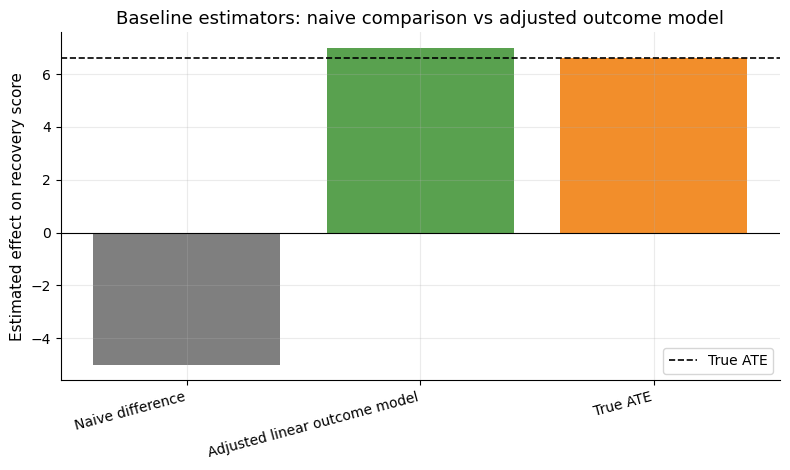

In [687]:
fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar(
    baseline_results["Estimator"],
    baseline_results["Estimated ATE"],
    color=[COLORS["gray"], COLORS["green"], COLORS["orange"]]
)

ax.axhline(
    true_ate,
    color="black",
    linewidth=1.2,
    linestyle="--",
    label="True ATE"
)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Baseline estimators: naive comparison vs adjusted outcome model")
ax.set_ylabel("Estimated effect on recovery score")
ax.legend()

plt.xticks(rotation=15, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()

The figure gives a visual summary of the baseline estimators.

- The gray bar shows the naive observed difference. It is below zero, which would incorrectly suggest that treatment reduces recovery. This happens because the treated group contains more severe patients.

- The green bar shows the adjusted outcome-model estimate. It is close to the dashed horizontal line, which marks the true ATE in the simulation. This indicates that adjustment has moved the estimate much closer to the causal target.

- The orange bar represents the true ATE, which is available only because we simulated the potential outcomes.

The main lesson is that adjustment can transform a misleading observational comparison into a more credible causal estimate. However, the adjusted linear model is still only a baseline. It may be insufficient when the outcome relationship is nonlinear or when treatment effects vary substantially across patients.

---
### 6.6 What this baseline teaches us

The baseline estimators provide three important lessons.

| Estimator | What it does | Main strength | Main limitation |
|---|---|---|---|
| Naive difference | Compares observed treated and untreated means | Simple and transparent | Biased when treatment assignment is confounded |
| Adjusted outcome model | Predicts outcomes under $T=1$ and $T=0$ after adjusting for $X$ | Connects directly to backdoor adjustment and standardization | Sensitive to omitted confounders and model misspecification |
| True ATE | Uses simulated potential outcomes | Useful for teaching and evaluation | Not available in real observational data |

The naive estimator is useful as a warning: it shows what can go wrong when treated and untreated groups are compared without adjustment.

The adjusted outcome model is a first step toward causal estimation. It uses the same covariate distribution for both treatment scenarios, which makes the comparison more aligned with the intervention question.

However, the adjusted linear model remains limited when:

- the outcome model is nonlinear,
- treatment effects vary across patients,
- the treatment assignment process is complex,
- high-dimensional covariates are involved,
- regularization or model choice affects the estimated treatment contrast.

These limitations motivate the next section on **meta-learners**, which use machine learning more explicitly to estimate heterogeneous treatment effects.

</br>

---
## 7. Meta-Learners: S-Learner, T-Learner, and X-Learner

Section 6 introduced adjusted outcome modeling as a first step toward causal effect estimation. The adjusted model compared predicted outcomes under two hypothetical treatment settings:

$$\hat{m}(1, X_i) - \hat{m}(0, X_i)$$

This is useful, but the linear model used in Section 6 is limited. It assumes a relatively simple relationship between covariates, treatment, and outcome. In many real applications, the response surface may be nonlinear, and the treatment effect may vary across individuals.

Meta-learners extend this idea by using standard supervised learning models to estimate treatment effects. They are called **meta-learners** because they are not a single algorithm. Instead, they are strategies for organizing prediction models around the causal treatment-effect problem.

The main target is the Conditional Average Treatment Effect:

$$\tau(x) = E[Y(1) - Y(0) \mid X=x]$$

where $X$ contains pre-treatment covariates such as `Age`, `Socioeconomic`, `Severity`, and `Biomarker`.

In this section, we study three common meta-learners:

1. **S-learner**: fits one outcome model using treatment and covariates together.
2. **T-learner**: fits separate outcome models for treated and untreated patients.
3. **X-learner**: imputes individual treatment effects and then models those imputed effects.

All three methods use machine learning for prediction, but the output is organized around causal contrasts.

The causal assumptions remain the same as before. Meta-learners do not remove the need for a valid adjustment set. We still assume that the relevant confounders are measured and included in $X$, and that treated and untreated patients have sufficient overlap in covariate space.


---
### 7.1 Prepare variables for meta-learners

The next code cell defines the common variables used by all three meta-learners.

We use the same pre-treatment adjustment variables as in Section 6:

- `Age`
- `Socioeconomic`
- `Severity`
- `Biomarker`

The outcome is `RecoveryScore`, and the treatment is `Treatment`.

This keeps the causal design consistent across sections: we estimate the total effect of treatment and avoid post-treatment variables such as `Inflammation`.

In [688]:
X_cov = health[adjustment_vars]
T = health["Treatment"].values
Y = health["RecoveryScore"].values

print("Covariates used for meta-learners:")
for var in adjustment_vars:
    print(f"- {var}")

print(f"\nOutcome: RecoveryScore")
print(f"Treatment: Treatment")
print(f"Number of patients: {len(health)}")
print(f"Treatment rate: {T.mean():.3f}")

Covariates used for meta-learners:
- Age
- Socioeconomic
- Severity
- Biomarker

Outcome: RecoveryScore
Treatment: Treatment
Number of patients: 3000
Treatment rate: 0.444


The output confirms the causal design used by all meta-learners in this section.

The covariates are `Age`, `Socioeconomic`, `Severity`, and `Biomarker`. These are all measured before treatment, so they are appropriate adjustment variables for estimating the total treatment effect. The post-treatment mediator `Inflammation` is deliberately excluded.

The treatment rate is about 0.44, meaning that roughly 44% of patients received treatment. This is not a randomized treatment rate. In the simulated data, treatment assignment depends on patient severity and biomarker values. Therefore, the meta-learners should be interpreted as observational causal estimators that rely on adjustment, not as estimators from a randomized experiment.

The important point is consistency: all meta-learners use the same treatment, outcome, and adjustment set. This makes the S-, T-, and X-learner results comparable.

---
### 7.2 S-learner

The **S-learner** fits a single outcome model using both treatment and covariates:

$$\hat{m}(T, X) \approx E[Y \mid T, X]$$

After fitting the model, we estimate the treatment effect for each patient by predicting the outcome twice:

$$\hat{\tau}^{S}(x) = \hat{m}(1, x) - \hat{m}(0, x)$$

The name “S-learner” comes from the fact that it uses a **single** model for both treated and untreated patients.

The S-learner is simple and often useful. However, because treatment is only one feature inside one predictive model, the model may understate treatment effects if the treatment signal is weak or if regularization smooths over treatment-effect heterogeneity.

The next code cell implements an S-learner using a random forest outcome model.

In [689]:
# S-learner with one random forest outcome model
s_features = ["Treatment"] + adjustment_vars

s_learner = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=42
)

# Fit one model using both treatment and pre-treatment covariates
s_learner.fit(health[s_features], Y)

# Predict each patient twice: once as treated and once as untreated
s_do1 = health[s_features].copy()
s_do0 = health[s_features].copy()

s_do1["Treatment"] = 1
s_do0["Treatment"] = 0

health["CATE_S_learner"] = s_learner.predict(s_do1) - s_learner.predict(s_do0)

s_ate = health["CATE_S_learner"].mean()

print(f"S-learner estimated ATE: {s_ate:.3f}")
print(f"True ATE:                {true_ate:.3f}")

S-learner estimated ATE: 5.097
True ATE:                6.608


The S-learner estimates a positive average treatment effect. This means that, according to the fitted model, assigning treatment increases the expected recovery score.

However, the S-learner estimate is lower than the true ATE in this simulation. The true ATE is available only because we generated the data ourselves.

This result is useful pedagogically. The S-learner uses one predictive model for both treated and untreated patients. Treatment is included as one feature among several strong predictors such as `Severity` and `Biomarker`. Because random forests are optimized for prediction, the model may focus more on strong prognostic variables and smooth over the treatment contrast.

The key lesson is:

> The S-learner is simple and intuitive, but it may underestimate treatment effects when treatment effects are heterogeneous or when the treatment signal is weaker than other predictive signals.

---
### 7.3 T-learner

The **T-learner** fits two separate outcome models:

$$\hat{m}_1(x) \approx E[Y \mid T=1, X=x]$$

and:

$$\hat{m}_0(x) \approx E[Y \mid T=0, X=x]$$

The treatment effect is estimated as:

$$\hat{\tau}^{T}(x) = \hat{m}_1(x) - \hat{m}_0(x)$$

The name “T-learner” comes from the fact that it uses **two** models: one for treated patients and one for untreated patients.

The T-learner allows the treated and untreated outcome surfaces to have different shapes. This can be useful when treatment changes the relationship between covariates and outcomes. However, it can be less stable if one treatment group is small or if treated and untreated patients occupy different regions of covariate space.

The next code cell implements a T-learner using two random forest outcome models.

In [690]:
# T-learner with two random forest outcome models
model_treated = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=42
)

model_control = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=43
)

# Fit one model among treated patients
model_treated.fit(
    health.loc[health["Treatment"] == 1, adjustment_vars],
    health.loc[health["Treatment"] == 1, "RecoveryScore"]
)

# Fit one model among untreated patients
model_control.fit(
    health.loc[health["Treatment"] == 0, adjustment_vars],
    health.loc[health["Treatment"] == 0, "RecoveryScore"]
)

# Predict potential outcomes for every patient
mu1_hat = model_treated.predict(health[adjustment_vars])
mu0_hat = model_control.predict(health[adjustment_vars])

health["CATE_T_learner"] = mu1_hat - mu0_hat

t_ate = health["CATE_T_learner"].mean()

print(f"T-learner estimated ATE: {t_ate:.3f}")
print(f"True ATE:                {true_ate:.3f}")

T-learner estimated ATE: 5.557
True ATE:                6.608


The T-learner also estimates a positive treatment effect, so it agrees with the direction of the true causal effect. Its estimate is closer to the true ATE than the S-learner in this run, but it still underestimates the true effect.

The T-learner is more flexible than the S-learner because it fits two separate models:

- one model for treated patients,
- one model for untreated patients.

This allows the treated and untreated outcome surfaces to have different shapes. However, this flexibility comes with a cost. Each model is trained on only part of the data.

In this example, treated patients tend to have higher severity, while untreated patients tend to have lower severity. As a result, each model may be less reliable when predicting outcomes for patients in regions where that treatment group has fewer examples. This is a practical overlap problem.

The key lesson is:

> The T-learner can capture more flexible treatment-response patterns than the S-learner, but it needs enough treated and untreated observations across the covariate space.

---
### 7.4 X-learner

The **X-learner** was designed to improve treatment-effect estimation when the treated and untreated groups are imbalanced or when treatment effects are heterogeneous.

It proceeds in three main steps.

First, it fits the same two outcome models used by the T-learner:

$$\hat{m}_1(x) \approx E[Y \mid T=1, X=x]$$

$$\hat{m}_0(x) \approx E[Y \mid T=0, X=x]$$

Second, it imputes treatment effects.

For treated patients, we observe $Y_i(1)$ and impute $Y_i(0)$ using the control model:

$$\tilde{D}_i^1 = Y_i - \hat{m}_0(X_i)$$

For untreated patients, we observe $Y_i(0)$ and impute $Y_i(1)$ using the treated model:

$$\tilde{D}_i^0 = \hat{m}_1(X_i) - Y_i$$

Third, it models these imputed treatment effects and combines them using the estimated propensity score:

$$\hat{e}(x) = P(T=1 \mid X=x)$$

A common combination rule is:

$$\hat{\tau}^{X}(x) = (1-\hat{e}(x))\hat{\tau}_1(x) + \hat{e}(x)\hat{\tau}_0(x)$$

The next code cell implements a teaching version of the X-learner using random forests.

In [691]:
# X-learner implementation for teaching
# Step 1: reuse outcome models from the T-learner

# Step 2: impute treatment effects for treated patients
D_treated = (
    health.loc[health["Treatment"] == 1, "RecoveryScore"].values
    - model_control.predict(health.loc[health["Treatment"] == 1, adjustment_vars])
)

# Step 2: impute treatment effects for untreated patients
D_control = (
    model_treated.predict(health.loc[health["Treatment"] == 0, adjustment_vars])
    - health.loc[health["Treatment"] == 0, "RecoveryScore"].values
)

# Step 3: model the imputed treatment effects
tau_model_treated = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=44
)

tau_model_control = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=45
)

tau_model_treated.fit(
    health.loc[health["Treatment"] == 1, adjustment_vars],
    D_treated
)

tau_model_control.fit(
    health.loc[health["Treatment"] == 0, adjustment_vars],
    D_control
)

# Estimate propensity scores
propensity_model = RandomForestClassifier(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=46
)

propensity_model.fit(health[adjustment_vars], health["Treatment"])
propensity_hat = propensity_model.predict_proba(health[adjustment_vars])[:, 1]

# Combine the two treatment-effect models
tau1_hat = tau_model_treated.predict(health[adjustment_vars])
tau0_hat = tau_model_control.predict(health[adjustment_vars])

health["CATE_X_learner"] = (1 - propensity_hat) * tau1_hat + propensity_hat * tau0_hat

x_ate = health["CATE_X_learner"].mean()

print(f"X-learner estimated ATE: {x_ate:.3f}")
print(f"True ATE:                {true_ate:.3f}")

X-learner estimated ATE: 6.713
True ATE:                6.608


The X-learner estimate is very close to the true ATE in this simulation.

This is because the X-learner uses a more structured strategy. It first uses outcome models to estimate missing counterfactual outcomes. Then it converts these into imputed treatment effects. Finally, it learns how those imputed effects vary across patient characteristics.

The propensity score helps combine the two treatment-effect models. Intuitively, the X-learner gives more weight to the treatment-effect model that is expected to be more reliable in a given region of the covariate space.

In this example, the X-learner performs well because treatment effects are heterogeneous and treatment assignment is imbalanced across severity levels.

The key lesson is:

> The X-learner can be effective when treatment effects vary across patients and treated and untreated groups are not perfectly balanced. However, it is also more complex and depends on several fitted models.

---
### 7.5 Compare meta-learner ATE estimates

The next code cell compares the ATE estimates from the three meta-learners with the true ATE.

Because this is a simulation, the true ATE is known. In real data, we would not have this benchmark. Instead, we would compare methods using robustness checks, overlap diagnostics, uncertainty intervals, and domain plausibility.

In [692]:
meta_learner_results = pd.DataFrame({
    "Meta-learner": [
        "S-learner",
        "T-learner",
        "X-learner",
        "True ATE"
    ],
    "Estimated ATE": [
        s_ate,
        t_ate,
        x_ate,
        true_ate
    ]
})

meta_learner_results["Absolute error vs true ATE"] = (
    meta_learner_results["Estimated ATE"] - true_ate
).abs()

meta_learner_results.round(3)

,Meta-learner,Estimated ATE,Absolute error vs true ATE
0,S-learner,5.097,1.510
1,T-learner,5.557,1.050
2,X-learner,6.713,0.105
3,True ATE,6.608,0.000


The table compares the estimated ATEs from the three meta-learners.

All three methods estimate a positive treatment effect, which is consistent with the true data-generating process. This is important: all meta-learners recover the correct qualitative conclusion that treatment improves recovery on average.

However, the numerical estimates differ. In this run:

- the S-learner underestimates the true ATE,
- the T-learner also underestimates the true ATE, but less severely,
- the X-learner is closest to the true ATE.

The `Absolute error vs true ATE` column is available only because this is a simulation. In real applications, the true ATE is unknown. We would instead compare methods using overlap diagnostics, sensitivity analysis, subgroup stability, confidence intervals, and domain knowledge.

The key lesson is:

> Different meta-learners can use the same data and the same covariates but still produce different estimates because they organize the prediction problem differently.

---
### 7.6 Visual comparison of meta-learners

The next code cell visualizes the ATE estimates from the S-, T-, and X-learners.

The dashed horizontal line marks the true ATE from the simulation. The purpose of the figure is to show how close each meta-learner is to the causal target in this controlled example.

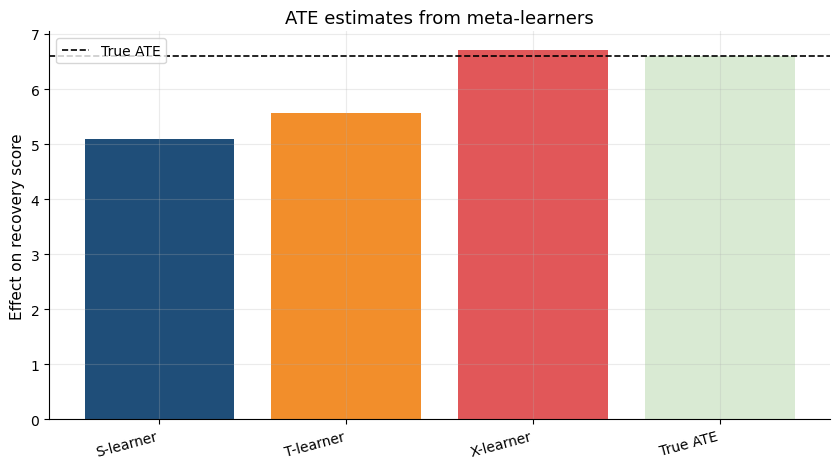

In [693]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.bar(
    meta_learner_results["Meta-learner"],
    meta_learner_results["Estimated ATE"],
    color=[COLORS["navy"], COLORS["orange"], COLORS["red"], COLORS["light_green"]]
)

ax.axhline(
    true_ate,
    color="black",
    linewidth=1.2,
    linestyle="--",
    label="True ATE"
)

ax.set_title("ATE estimates from meta-learners")
ax.set_ylabel("Effect on recovery score")
ax.legend()

plt.xticks(rotation=15, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()

The figure provides a visual comparison of the meta-learner estimates.

The dashed horizontal line shows the true ATE from the simulation. The closer a bar is to this line, the closer the estimator is to the true average treatment effect.

- The **S-learner** bar is below the true ATE. This reflects the tendency of a single predictive model to smooth the treatment contrast.

- The **T-learner** bar is also below the true ATE, but it is closer than the S-learner because it uses separate outcome models for treated and untreated patients.

- The **X-learner** bar is closest to the true ATE in this simulation. This reflects its use of imputed treatment effects and propensity-based weighting.

> The main lesson is not that the X-learner is always best. Rather, the lesson is that meta-learner design matters. Different learners make different trade-offs between simplicity, flexibility, data efficiency, and sensitivity to overlap.

---
### 7.7 Summary of meta-learners

| Learner | Main idea | Strength | Limitation |
|---|---|---|---|
| S-learner | Fit one model $\hat{m}(T, X)$ and contrast predictions under $T=1$ and $T=0$ | Simple and easy to implement | May shrink or smooth treatment effects |
| T-learner | Fit separate models $\hat{m}_1(X)$ and $\hat{m}_0(X)$ for treated and untreated groups | Allows different response surfaces for treated and untreated patients | Sensitive to small sample size or weak overlap in one group |
| X-learner | Impute treatment effects, model them, and combine using propensity scores | Useful for heterogeneous effects and imbalanced treatment groups | More complex and depends on several fitted models |

Meta-learners provide a practical bridge between supervised learning and causal effect estimation. They use prediction models, but their purpose is not ordinary prediction. Their purpose is to estimate causal contrasts such as:

$$\hat{\tau}(x) = \hat{Y}(1 \mid X=x) - \hat{Y}(0 \mid X=x)$$

The results in this section show that meta-learners can recover the positive treatment effect more effectively than a naive comparison. They also show that different meta-learners can produce different numerical estimates.

This is expected. Each learner makes different modeling choices:

- the S-learner uses one shared model,
- the T-learner uses two separate outcome models,
- the X-learner imputes treatment effects and models them directly.

Meta-learners are useful, but they are not automatic causal machines. Their estimates are meaningful only if the causal design is credible:

- the treatment and outcome are clearly defined,
- the adjustment variables are measured before treatment,
- important confounders are not omitted,
- treated and untreated patients have sufficient overlap,
- results are interpreted as estimates under assumptions, not as proof of causality.

The next section moves from average effects to heterogeneity. We will use the estimated CATE values to study which patients are predicted to benefit more or less from treatment.

</br>

---
## 8. Heterogeneous Treatment Effects and CATE Visualization

The previous section introduced meta-learners and showed that they can estimate individual-level treatment effects:

$$\hat{\tau}(x) = \hat{Y}(1 \mid X=x) - \hat{Y}(0 \mid X=x)$$

The average of these individual estimates gives an estimated ATE. However, the ATE only answers the average question:

> *Does the treatment improve recovery on average?*

In many real applications, the more useful question is:

> *Which patients benefit more, and which patients benefit less?*

This is the motivation for estimating the Conditional Average Treatment Effect:

$$CATE(x) = E[Y(1) - Y(0) \mid X=x]$$

In this healthcare example, the true simulated treatment effect depends partly on `Severity`, `Biomarker`, and `Age`. Treatment tends to help more for patients with higher baseline severity and worse biomarker profiles, but slightly less for older patients.

Because this is a simulation, we can compare the estimated CATE values with the known true treatment effects. In real applications, the true CATE is not observed. We would instead rely on domain knowledge, overlap diagnostics, uncertainty analysis, subgroup stability, and external validation when available.

This section has three goals:

1. compare average treatment-effect estimates across methods,
2. visualize how estimated treatment effects vary by baseline severity,
3. explain how heterogeneous treatment effects can support better decisions.


---
### 8.1 Compare ATE estimates across methods

Before studying heterogeneity, we first compare the average treatment-effect estimates across the methods introduced so far.

The next code cell creates a table with:

- the naive difference,
- the adjusted linear outcome model,
- the S-learner,
- the T-learner,
- the X-learner,
- the true ATE from the simulation.

This comparison helps us see how different methods move from a biased observational comparison toward the causal target.

In [694]:
# Compare ATE estimates from methods introduced so far
ate_comparison = pd.DataFrame({
    "Method": [
        "Naive difference",
        "Adjusted linear model",
        "S-learner",
        "T-learner",
        "X-learner",
        "True ATE",
    ],
    "Estimated ATE": [
        naive_effect,
        lin_adjusted_effect,
        s_ate,
        t_ate,
        x_ate,
        true_ate,
    ]
})

ate_comparison["Absolute error vs true ATE"] = (
    ate_comparison["Estimated ATE"] - true_ate
).abs()

ate_comparison.round(3)

,Method,Estimated ATE,Absolute error vs true ATE
0,Naive difference,-4.999,11.606
1,Adjusted linear model,6.983,0.375
2,S-learner,5.097,1.510
3,T-learner,5.557,1.050
4,X-learner,6.713,0.105
5,True ATE,6.608,0.000


The table summarizes how each method estimates the average effect of treatment on `RecoveryScore`.

The naive difference is strongly misleading. It estimates a negative effect of about $-5$ recovery-score points, even though the true ATE is positive. This happens because treated patients are more severe at baseline. The naive comparison therefore mixes treatment effect with baseline health differences.

The adjusted linear model is much closer to the true ATE. This shows the value of adjusting for pre-treatment covariates such as `Age`, `Socioeconomic`, `Severity`, and `Biomarker`.

The S-learner and T-learner also recover the correct direction of the effect: both estimate that treatment improves recovery. However, they underestimate the true ATE in this simulation. This suggests that their fitted models may smooth over some of the treatment-effect heterogeneity.

The X-learner is closest to the true ATE among the meta-learners. In this simulation, it benefits from modeling imputed treatment effects and combining them using propensity-score information.

The important lesson is:

> Adjustment and causal ML methods substantially improve over the naive comparison, but different methods can still produce different estimates.

This is why method comparison is useful. It helps us see whether the causal conclusion is stable or sensitive to modeling choices.

---
### 8.2 Visualize ATE estimates

The next code cell visualizes the same comparison.

The dashed horizontal line shows the true ATE from the simulation. Bars closer to this line are closer to the true average causal effect.

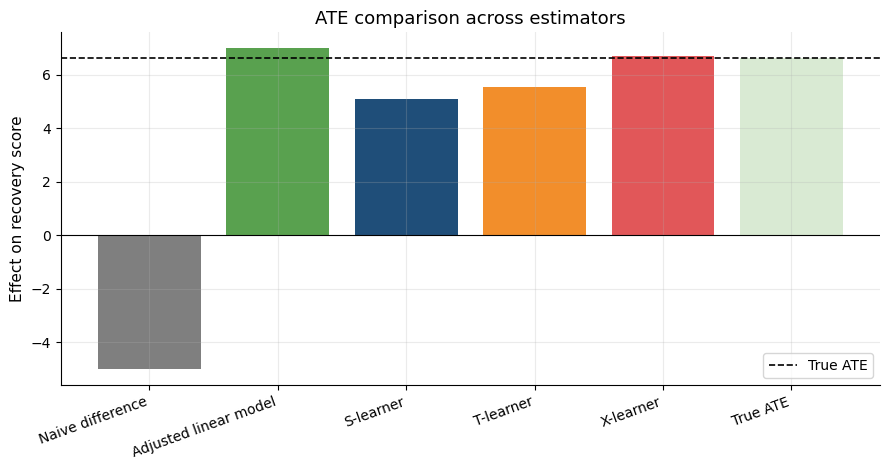

In [695]:
fig, ax = plt.subplots(figsize=(9, 4.8))

colors = [
    COLORS["gray"],
    COLORS["green"],
    COLORS["navy"],
    COLORS["orange"],
    COLORS["red"],
    COLORS["light_green"],
]

ax.bar(
    ate_comparison["Method"],
    ate_comparison["Estimated ATE"],
    color=colors
)

ax.axhline(
    true_ate,
    color="black",
    linewidth=1.2,
    linestyle="--",
    label="True ATE"
)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("ATE comparison across estimators")
ax.set_ylabel("Effect on recovery score")
ax.legend()

plt.xticks(rotation=20, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()

The figure shows the same comparison visually.

- The gray bar represents the naive difference. It is below zero, which would suggest that treatment reduces recovery if interpreted causally. This conclusion is wrong in the simulation because the treated group contains more severe patients.

- The green bar shows the adjusted linear model. It is close to the dashed horizontal line, which represents the true ATE. This confirms that adjustment for pre-treatment covariates moves the estimate much closer to the causal target.

- The S-learner and T-learner bars are positive but below the true ATE. These models identify the beneficial direction of treatment but underestimate the average effect.

- The X-learner bar is closest to the true ATE in this example. This does not mean that the X-learner is always the best method. It means that, for this simulated dataset, the X-learner structure is well matched to the heterogeneity and treatment imbalance in the data.

> The main observation is that the ATE comparison is useful, but it is still only an average. It does not show whether the treatment effect is similar for all patients or concentrated in specific subgroups. That is why we next examine CATE by severity.

---
### 8.3 Compare CATE by severity group

The next code cell summarizes the true and estimated treatment effects within the same four severity groups introduced earlier in the chapter.

We use `SeverityGroup` because the simulation was designed so that treatment effects increase with baseline severity. Keeping the same four groups throughout the chapter makes the comparison easier to follow.

For each severity group, we compute:

- number of patients,
- average severity,
- true CATE from the simulated treatment effect,
- estimated CATE from the S-learner,
- estimated CATE from the T-learner,
- estimated CATE from the X-learner.

In [696]:
# Use the same four severity groups defined earlier in the chapter.
# Do not redefine SeverityGroup here.

cate_by_severity = health.groupby("SeverityGroup", observed=True).agg(
    patients=("RecoveryScore", "size"),
    mean_severity=("Severity", "mean"),
    true_cate=("TrueTreatmentEffect", "mean"),
    s_learner=("CATE_S_learner", "mean"),
    t_learner=("CATE_T_learner", "mean"),
    x_learner=("CATE_X_learner", "mean"),
).reset_index()

cate_by_severity.round(3)

,SeverityGroup,patients,mean_severity,true_cate,s_learner,t_learner,x_learner
0,Low severity,750,-1.585,5.534,2.234,2.843,6.121
1,Medium-low,750,-0.419,6.209,6.231,6.279,6.361
2,Medium-high,750,0.370,6.998,7.070,7.087,7.034
3,High severity,750,1.554,7.690,4.853,6.019,7.334


The table shows how treatment effects vary across the four baseline severity groups.

Each row represents one severity group. Because the groups were created using quartiles, each group contains approximately the same number of patients.

The `mean_severity` column increases from low-severity patients to high-severity patients. The `true_cate` column shows the known simulated treatment effect within each group. Since the simulation was designed so that treatment helps more for patients with higher baseline severity, we expect `true_cate` to increase from the low-severity group to the high-severity group.

The estimated CATE columns show how well each meta-learner recovers this pattern.

The main point to observe is whether the estimated effects are:

1. positive across severity groups, and  
2. larger for higher-severity patients.

A method may estimate a reasonable ATE but still miss important subgroup-level treatment-effect patterns. This is why CATE analysis is important for decision-making.

---
### 8.4 Visualize CATE by baseline severity

The next code cell plots the true and estimated CATE values against average baseline severity.

This is the most important visualization in this section. It shows whether each method captures the direction and shape of treatment-effect heterogeneity.

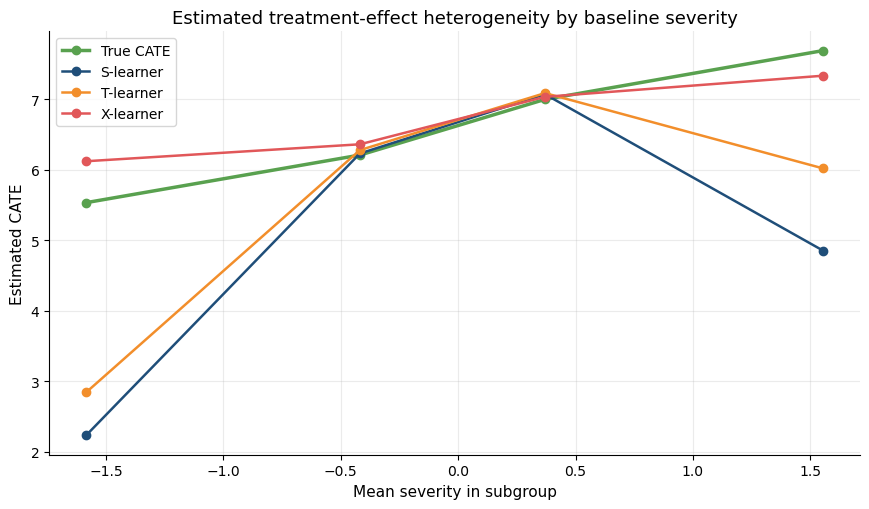

In [697]:
fig, ax = plt.subplots(figsize=(8.8, 5.2))

ax.plot(
    cate_by_severity["mean_severity"],
    cate_by_severity["true_cate"],
    marker="o",
    linewidth=2.5,
    label="True CATE",
    color=COLORS["green"]
)

ax.plot(
    cate_by_severity["mean_severity"],
    cate_by_severity["s_learner"],
    marker="o",
    linewidth=1.8,
    label="S-learner",
    color=COLORS["navy"]
)

ax.plot(
    cate_by_severity["mean_severity"],
    cate_by_severity["t_learner"],
    marker="o",
    linewidth=1.8,
    label="T-learner",
    color=COLORS["orange"]
)

ax.plot(
    cate_by_severity["mean_severity"],
    cate_by_severity["x_learner"],
    marker="o",
    linewidth=1.8,
    label="X-learner",
    color=COLORS["red"]
)

ax.set_title("Estimated treatment-effect heterogeneity by baseline severity")
ax.set_xlabel("Mean severity in subgroup")
ax.set_ylabel("Estimated CATE")
ax.legend()

clean_axis(ax)
plt.tight_layout()
plt.show()

The CATE plot provides the main visual result in this section.

- The green curve shows the true simulated CATE across the four severity groups. It increases with baseline severity, meaning that more severe patients benefit more from treatment.

- The red curve shows the X-learner estimate. If it follows the green curve, then it captures the main heterogeneity structure: treatment benefit rises as severity increases.

- The navy and orange curves show the S-learner and T-learner estimates. These methods may capture the general direction of the effect, but they can still underestimate treatment effects in some groups.

The main lesson is:

> CATE estimation is not only about estimating whether treatment works. It is about estimating for whom it works more or less.

In this simulation, the treatment is beneficial across all severity groups, but the expected benefit is larger for high-severity patients. This type of result can support treatment prioritization, but only after checking overlap, uncertainty, and domain plausibility.

---
### 8.5 Why CATE matters for decisions

CATE estimates can support more targeted decisions.

In the healthcare example, the positive ATE suggests that the treatment is beneficial on average. However, CATE estimates provide a more detailed view. They help answer questions such as:

- Which patients are expected to benefit most?
- Are high-severity patients likely to gain more from treatment?
- Are there patient groups where the treatment benefit is small?
- Do different meta-learners agree on the same heterogeneity pattern?

A useful way to interpret CATE is:

| CATE pattern | Possible decision implication |
|---|---|
| Positive CATE for almost all groups | Treatment may be broadly useful |
| Larger CATE for high-severity patients | Treatment may be prioritized for severe cases |
| Near-zero CATE for some groups | Treatment benefit may be limited for those patients |
| Negative CATE for some groups | Treatment may be harmful or inappropriate for those patients |
| Strong disagreement across learners | More diagnostics and validation are needed |

In this simulation, the true treatment effect is positive for all severity groups and larger for more severe patients. Therefore, the treatment appears broadly beneficial, with stronger expected benefit for high-severity patients.

In real applications, this type of result should be interpreted carefully. A CATE estimate should support decision-making, but it should not automatically determine treatment allocation without clinical, ethical, and statistical validation.

---
### 8.6 Practical cautions when interpreting CATE

CATE estimation is powerful, but it is also more difficult than ATE estimation.

There are several reasons:

1. **CATE is a local quantity**  
   It estimates treatment effects for subgroups or individual profiles. This requires more information than estimating one population average.

2. **Overlap matters more strongly**  
   If high-severity patients are mostly treated and low-severity patients are mostly untreated, then counterfactual prediction becomes difficult in those regions.

3. **Model choice matters**  
   Different learners may produce different heterogeneity patterns because they organize the estimation problem differently.

4. **Uncertainty is often larger**  
   Subgroup estimates are usually less stable than population-level estimates.

5. **Causal assumptions still matter**  
   If important confounders are missing, CATE estimates can be biased even when the machine learning model is flexible.

The practical rule is:

> Use CATE estimates as decision-support evidence, not as automatic decision rules.

A responsible CATE analysis should include overlap checks, uncertainty intervals, robustness across methods, and domain interpretation.

---
### 8.7 Summary of heterogeneous treatment effects

This section moved from average treatment effects to heterogeneous treatment effects.

The main points are:

- ATE summarizes the average treatment effect in the population.
- CATE shows how the treatment effect varies across patient characteristics.
- In this simulation, the true treatment effect increases across the four baseline severity groups.
- The X-learner generally follows the severity-related heterogeneity pattern better than the S-learner and T-learner in this specific run.
- The S-learner and T-learner still recover the positive direction of the effect, but they underestimate effects at the severity extremes.
- A good ATE estimate does not guarantee a good CATE estimate.
- CATE estimates are useful for targeting and prioritization, but they require careful interpretation.

The next section introduces **Double Machine Learning**, which focuses on estimating causal effects with flexible machine learning while reducing bias from nuisance-function estimation.

</br>

---
## 9. Double Machine Learning: Orthogonalization and Sample Splitting

Sections 7 and 8 introduced meta-learners for estimating average and heterogeneous treatment effects. Meta-learners are intuitive because they estimate potential outcomes and compare predicted outcomes under treatment and no treatment.

**Double Machine Learning**, often abbreviated as **DML**, takes a different approach.

DML is designed to estimate causal effects while using flexible machine learning models for two supporting prediction tasks:

1. predicting the outcome from covariates,
2. predicting treatment assignment from covariates.

These supporting models are called **nuisance models**. They are important, but they are not the final causal target.

In this section, the target is the average treatment effect of `Treatment` on `RecoveryScore`, adjusted for the pre-treatment covariates:

- `Age`
- `Socioeconomic`
- `Severity`
- `Biomarker`

The main idea of DML is:

> First remove from both the outcome and the treatment the parts that can be predicted from pre-treatment covariates. Then estimate the treatment effect using the remaining variation.

For a partially linear model, we can write:

$$Y = \theta T + g(X) + \varepsilon$$

and:

$$T = e(X) + \eta$$

where:

- $Y$ is the outcome, `RecoveryScore`,
- $T$ is the treatment, `Treatment`,
- $X$ contains pre-treatment covariates,
- $\theta$ is the average causal effect parameter of interest,
- $g(X) = E[Y \mid X]$ describes how covariates predict the outcome,
- $e(X) = E[T \mid X]$ is the propensity function,
- $\varepsilon$ and $\eta$ are residual terms.


DML estimates $g(X)$ and $e(X)$ using machine learning, then constructs residuals:

$$\tilde{Y} = Y - \hat{g}(X)$$

$$\tilde{T} = T - \hat{e}(X)$$


Finally, it estimates the treatment effect by regressing the residualized outcome on the residualized treatment:

$$\hat{\theta}_{DML} = \frac{\sum_i \tilde{T}_i \tilde{Y}_i}{\sum_i \tilde{T}_i^2}$$

This procedure is called **orthogonalization** because it removes the parts of the outcome and treatment that are explained by the covariates.

DML also uses **sample splitting** or **cross-fitting**. This means that the nuisance models are trained on one part of the data and used to create residuals on another part. This helps reduce overfitting bias from flexible machine learning models.


The key point is:

> DML uses machine learning for prediction, but the final estimation step is organized around the causal effect.

---
### 9.1 A simple implementation of cross-fitted DML

The next code cell defines a simple teaching implementation of DML.

The function performs four steps:

1. split the data into folds,
2. train an outcome model $\hat{g}(X)$ and a treatment model $\hat{e}(X)$ on the training folds,
3. predict outcome and treatment on the held-out fold,
4. compute residuals $\tilde{Y}$ and $\tilde{T}$ for the held-out fold.

After all folds are processed, the function estimates the treatment effect using the residualized outcome and residualized treatment.

This implementation is intentionally simple so that the main idea of DML is visible. Production applications usually use specialized packages such as `DoubleML` or `EconML`.

In [698]:
def cross_fitted_dml_ate(df, outcome, treatment, covariates, n_splits=5, seed=42):
    """Simple implementation of cross-fitted DML for a partially linear ATE.

    This function estimates one average treatment effect.
    It does not estimate heterogeneous treatment effects.
    """

    X = df[covariates].values
    Y = df[outcome].values
    T = df[treatment].values

    y_residual = np.zeros(len(df))
    t_residual = np.zeros(len(df))

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train = Y[train_idx]
        T_train = T[train_idx]

        # Outcome nuisance model: g(X) = E[Y | X]
        outcome_model = RandomForestRegressor(
            n_estimators=120,
            min_samples_leaf=20,
            random_state=seed
        )

        # Treatment nuisance model: e(X) = P(T = 1 | X)
        treatment_model = RandomForestClassifier(
            n_estimators=120,
            min_samples_leaf=20,
            random_state=seed
        )

        outcome_model.fit(X_train, Y_train)
        treatment_model.fit(X_train, T_train)

        # Predict on the held-out fold
        y_hat = outcome_model.predict(X_test)
        t_hat = treatment_model.predict_proba(X_test)[:, 1]

        # Residualize outcome and treatment
        y_residual[test_idx] = Y[test_idx] - y_hat
        t_residual[test_idx] = T[test_idx] - t_hat

    # Final residual-on-residual regression coefficient
    theta_hat = np.sum(t_residual * y_residual) / np.sum(t_residual ** 2)

    return theta_hat, y_residual, t_residual

The function above does not produce numerical output yet. It defines the DML procedure that will be applied in the next cell.

The important feature is **cross-fitting**. Each observation is evaluated using nuisance models that were trained on other observations. This reduces the risk that flexible machine learning models overfit the same data used to estimate the final treatment effect.

The function returns three outputs:

- `theta_hat`: the DML estimate of the average treatment effect,
- `y_residual`: the part of `RecoveryScore` that remains after removing what can be predicted from pre-treatment covariates,
- `t_residual`: the part of `Treatment` that remains after removing what can be predicted from pre-treatment covariates.

The key idea is that DML separates two tasks:

1. use machine learning to predict outcome and treatment assignment from covariates,
2. estimate the causal effect using the residualized treatment-outcome relationship.

This separation is what makes DML different from simply fitting a predictive model with `Treatment` as one feature.

---
### 9.2 Estimate the DML average treatment effect

The next code cell applies the DML function to the healthcare dataset.

We use only pre-treatment variables as covariates. This is important because the goal is to estimate the total effect of treatment. The post-treatment mediator `Inflammation` is excluded for the same reason as before.

In [699]:
# Important: use only pre-treatment variables as covariates for total-effect estimation.
dml_ate, y_resid, t_resid = cross_fitted_dml_ate(
    health,
    outcome="RecoveryScore",
    treatment="Treatment",
    covariates=adjustment_vars,
    n_splits=5,
    seed=42,
)

print(f"DML estimated ATE: {dml_ate:.3f}")
print(f"True ATE:          {true_ate:.3f}")

DML estimated ATE: 6.632
True ATE:          6.608


The DML estimate is very close to the true ATE in this simulation.

The estimated effect is approximately 6.6 recovery-score points, which means that assigning treatment is estimated to increase the average recovery score by about 6.6 points. Since the true ATE is also about 6.6, DML performs very well in this controlled example.

This result is important because earlier in the chapter the naive comparison suggested a negative effect. That naive result was misleading because treated patients were more severe at baseline. DML corrects for this by modeling:

$$g(X) = E[Y \mid X]$$

and:

$$e(X) = E[T \mid X]$$

Then it estimates the treatment effect using what remains after removing the covariate-predictable parts of both outcome and treatment.

In real observational data, the true ATE would not be available. Here, it is used only for teaching and evaluation. In practice, we would need diagnostics, uncertainty estimates, sensitivity analysis, and domain knowledge to judge whether the DML estimate is credible.

---
### 9.3 Visualize residualization

The next code cell visualizes the difference between the original data and the residualized DML view.

The left plot shows the original relationship between treatment and recovery score. This view is confounded because treatment assignment depends on patient characteristics.

The right plot shows the residualized relationship. Both treatment and recovery have been adjusted for pre-treatment covariates. The slope of the red line represents the DML estimate.

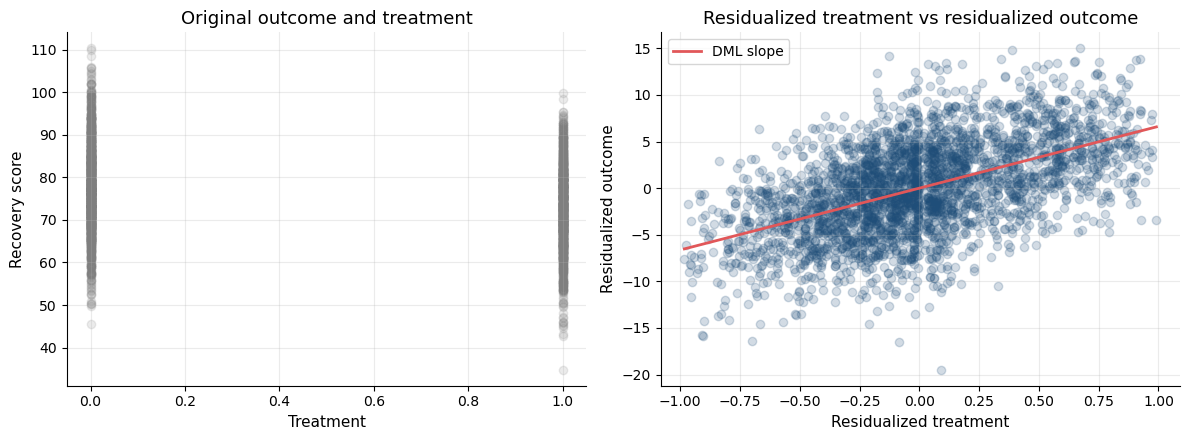

In [700]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Original treatment-outcome relationship
axes[0].scatter(
    health["Treatment"],
    health["RecoveryScore"],
    alpha=0.15,
    color=COLORS["gray"]
)
axes[0].set_title("Original outcome and treatment")
axes[0].set_xlabel("Treatment")
axes[0].set_ylabel("Recovery score")
clean_axis(axes[0])

# Residualized relationship
x_line = np.linspace(t_resid.min(), t_resid.max(), 100)
coef_line = dml_ate * x_line

axes[1].scatter(
    t_resid,
    y_resid,
    alpha=0.20,
    color=COLORS["navy"]
)
axes[1].plot(
    x_line,
    coef_line,
    color=COLORS["red"],
    linewidth=2,
    label="DML slope"
)
axes[1].set_title("Residualized treatment vs residualized outcome")
axes[1].set_xlabel("Residualized treatment")
axes[1].set_ylabel("Residualized outcome")
axes[1].legend()
clean_axis(axes[1])

plt.tight_layout()
plt.show()

The two plots show the difference between the raw observational view and the DML residualized view.

The left plot shows the original relationship between `Treatment` and `RecoveryScore`. This plot is not causal by itself. Treated and untreated patients differ before treatment, especially in baseline severity and biomarker values. Therefore, the raw treatment-outcome relationship is confounded.

The right plot shows the DML residualized relationship. The x-axis is residualized treatment:

$$\tilde{T} = T - \hat{e}(X)$$

This is the part of treatment assignment that remains after accounting for pre-treatment covariates.

The y-axis is residualized outcome:

$$\tilde{Y} = Y - \hat{g}(X)$$

This is the part of recovery score that remains after accounting for the same covariates.

The red line represents the slope from residualized treatment to residualized outcome. This slope is the DML treatment-effect estimate.

The important lesson is:

> DML estimates the treatment effect after removing the parts of both treatment and outcome that are predictable from observed confounders. This is why DML is useful when treatment assignment and outcomes depend on nonlinear or complex covariate relationships.

---
### 9.4 Compare DML with previous ATE estimates

The next code cell compares DML with the estimators introduced earlier.

This helps position DML within the chapter. DML is not a replacement for causal design. It is another estimator that uses machine learning in a structured way.

In [701]:
dml_comparison = pd.DataFrame({
    "Method": [
        "Naive difference",
        "Adjusted linear model",
        "S-learner",
        "T-learner",
        "X-learner",
        "DML",
        "True ATE",
    ],
    "Estimated ATE": [
        naive_effect,
        lin_adjusted_effect,
        s_ate,
        t_ate,
        x_ate,
        dml_ate,
        true_ate,
    ]
})

dml_comparison["Absolute error vs true ATE"] = (
    dml_comparison["Estimated ATE"] - true_ate
).abs()

dml_comparison.round(3)

,Method,Estimated ATE,Absolute error vs true ATE
0,Naive difference,-4.999,11.606
1,Adjusted linear model,6.983,0.375
2,S-learner,5.097,1.510
3,T-learner,5.557,1.050
4,X-learner,6.713,0.105
5,DML,6.632,0.024
6,True ATE,6.608,0.000


The table compares DML with the estimators introduced earlier in the chapter.

- The naive difference remains the most misleading estimate. It is negative and far from the true ATE because it does not adjust for confounding.

- The adjusted linear model performs much better. It becomes positive and close to the true ATE because it adjusts for pre-treatment covariates. However, it relies on a simple linear outcome model.

- The S-learner and T-learner also estimate positive effects, but both underestimate the true ATE in this simulation. These methods are useful for heterogeneous treatment-effect estimation, but their average estimates can still be affected by smoothing, overlap problems, or model structure.

- The X-learner is very close to the true ATE. It performed well in this example because it directly models imputed treatment effects and uses propensity information.

- DML is the closest method in this table. Its absolute error is very small because it effectively residualizes both treatment and outcome with respect to the observed confounders.

The key lesson is:

> DML is especially useful when the goal is a reliable average treatment-effect estimate and the nuisance relationships are complex enough to benefit from machine learning.

---
### 9.5 Visual comparison including DML

The next code cell visualizes the comparison table.

The dashed horizontal line marks the true ATE from the simulation. The purpose of the figure is to show where DML sits relative to the previous estimators.

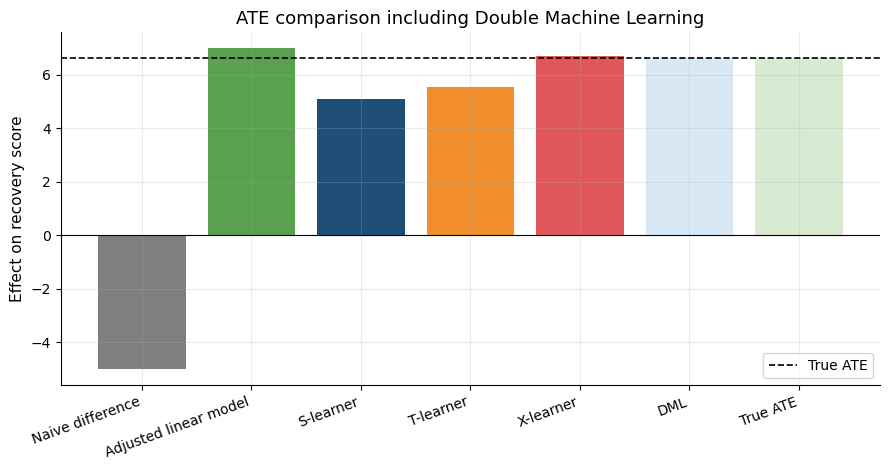

In [702]:
fig, ax = plt.subplots(figsize=(9, 4.8))

plot_colors = [
    COLORS["gray"],
    COLORS["green"],
    COLORS["navy"],
    COLORS["orange"],
    COLORS["red"],
    COLORS["light_blue"],
    COLORS["light_green"],
]

ax.bar(
    dml_comparison["Method"],
    dml_comparison["Estimated ATE"],
    color=plot_colors
)

ax.axhline(
    true_ate,
    color="black",
    linewidth=1.2,
    linestyle="--",
    label="True ATE"
)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("ATE comparison including Double Machine Learning")
ax.set_ylabel("Effect on recovery score")
ax.legend()

plt.xticks(rotation=20, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()

The figure shows the comparison visually.

The dashed horizontal line is the true ATE from the simulation. Bars closer to this line are closer to the true causal effect.

- The gray bar for the naive difference is below zero, showing again that the raw observational comparison gives the wrong direction.

- The adjusted linear model is close to the true ATE, showing the value of adjustment. The S- and T-learners are positive but below the true effect. The X-learner is very close to the true ATE.

- The DML bar is almost aligned with the true ATE line. This shows that, in this simulation, residualizing both treatment and outcome using flexible nuisance models produces a very accurate average treatment-effect estimate.

However, this should not be interpreted as proof that DML is always best. DML performs well here because the important confounders are observed, included in the model, and reasonably well captured by the random forests.

The broader lesson is:

> DML is powerful when the causal design is credible and when machine learning is used to estimate nuisance functions rather than to replace causal reasoning.

---
### 9.6 What DML teaches us

DML provides three important lessons for causal machine learning.

| Concept | Meaning | Why it matters |
|---|---|---|
| Nuisance models | Predict $Y$ from $X$ and predict $T$ from $X$ | Machine learning is used for flexible prediction where it is most useful |
| Orthogonalization | Remove from $Y$ and $T$ the parts explained by $X$ | Helps isolate the treatment variation that is less confounded by observed covariates |
| Cross-fitting | Train nuisance models on one fold and residualize another fold | Reduces overfitting bias from flexible machine learning |

DML is useful when the outcome model and treatment assignment model may be nonlinear or high-dimensional. It helps separate the predictive tasks from the causal estimation task.

However, DML does not solve all causal problems. It still requires:

- a clearly defined treatment and outcome,
- a valid pre-treatment adjustment set,
- no important unmeasured confounders,
- sufficient overlap between treated and untreated patients,
- careful interpretation of the estimand.

In this chapter, our DML implementation estimates one average effect. It does not estimate heterogeneous effects by itself. For heterogeneous effects, we use meta-learners or specialized methods such as causal forests.

The practical message is:

> DML is a disciplined way to combine machine learning with causal estimation, but it still depends on causal assumptions.

---
### 9.7 Summary of Double Machine Learning

This section introduced Double Machine Learning as a method for estimating an average treatment effect using flexible nuisance models.

The main points are:

- DML estimates the average effect of `Treatment` on `RecoveryScore`.
- It uses machine learning to estimate $g(X) = E[Y \mid X]$ and $e(X) = E[T \mid X]$.
- It residualizes both outcome and treatment with respect to pre-treatment covariates.
- It estimates the treatment effect from the residualized relationship between $\tilde{T}$ and $\tilde{Y}$.
- Cross-fitting helps reduce overfitting bias from flexible machine learning models.
- In this simulation, DML gives an estimate very close to the true ATE.
- DML is useful for average treatment-effect estimation, but it does not remove the need for causal assumptions or a valid adjustment set.

The next section provides an optional demonstration using `EconML`, a specialized Python package for causal machine learning.

</br>

---
## 10. Optional EconML Demonstration

So far, we implemented causal machine learning methods using standard `scikit-learn` tools. This was useful for teaching because the logic of each method was visible in the code.

In applied projects, researchers and practitioners often use specialized causal machine learning libraries. One widely used Python library is **EconML**, developed by Microsoft Research. EconML includes implementations of methods such as:

- `LinearDML`
- `CausalForestDML`
- `DRLearner`
- meta-learners and related heterogeneous treatment-effect estimators

This section is optional. The rest of the notebook does not depend on EconML.

The goal is not to teach all details of the package. Instead, the goal is to show how a specialized library follows the same causal workflow used throughout this chapter:

1. define the treatment,
2. define the outcome,
3. define pre-treatment covariates,
4. choose the estimand,
5. estimate ATE and CATE,
6. visualize treatment-effect heterogeneity,
7. interpret the result cautiously.

In this demonstration, we use `CausalForestDML`. It combines two ideas already introduced in the chapter:

- the DML idea of using nuisance models for outcome and treatment assignment,
- the causal forest idea of estimating heterogeneous treatment effects.

If EconML is not installed, the notebook will print installation instructions and continue.

In Google Colab, EconML can usually be installed with:

```python
!pip install econml


---
### 10.1 Check whether EconML is available

The next code cell checks whether `EconML` is installed.

If the package is available, the notebook will import `CausalForestDML`. If it is not available, the notebook will print a short message and skip the optional demonstration.

In [703]:
try:
    from econml.dml import CausalForestDML
    econml_available = True
    print("EconML is available. The optional demonstration will run.")
except Exception:
    econml_available = False
    print("EconML is not installed in this environment.")
    print("In Google Colab, install it with: !pip install econml")

EconML is not installed in this environment.
In Google Colab, install it with: !pip install econml


If EconML is available, the output confirms that the optional demonstration can run.

If EconML is not installed, this is not a problem. The rest of the chapter remains complete. The optional section is included only to show how the same causal machine learning workflow can be implemented with a specialized package.

---
### 10.2 Fit a CausalForestDML model

The next code cell fits a `CausalForestDML` estimator if EconML is available.

We use the same design as before:

- outcome: `RecoveryScore`
- treatment: `Treatment`
- covariates: `Age`, `Socioeconomic`, `Severity`, and `Biomarker`

The post-treatment mediator `Inflammation` is excluded because the target remains the total effect of treatment.

The estimator uses random forest models as nuisance models for the outcome and treatment assignment processes. It then estimates heterogeneous treatment effects using a causal forest-style approach.

In [704]:
if econml_available:
    X_econml = health[adjustment_vars]
    T_econml = health["Treatment"]
    Y_econml = health["RecoveryScore"]

    cf_dml = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=100,
            min_samples_leaf=20,
            random_state=42
        ),
        model_t=RandomForestClassifier(
            n_estimators=100,
            min_samples_leaf=20,
            random_state=42
        ),
        discrete_treatment=True,
        n_estimators=120,
        min_samples_leaf=20,
        random_state=42,
    )

    cf_dml.fit(Y_econml, T_econml, X=X_econml)

    health["CATE_EconML_CausalForestDML"] = cf_dml.effect(X_econml)
    econml_ate = health["CATE_EconML_CausalForestDML"].mean()

    print(f"EconML CausalForestDML estimated ATE: {econml_ate:.3f}")
    print(f"True ATE:                              {true_ate:.3f}")
else:
    print("Skipping CausalForestDML because EconML is not installed.")

Skipping CausalForestDML because EconML is not installed.


If EconML is installed, the output reports the estimated ATE from `CausalForestDML` and compares it with the true ATE from the simulation.

The estimated ATE is computed by averaging the individual CATE estimates produced by the causal forest:

$$\widehat{ATE} = \frac{1}{n}\sum_{i=1}^{n}\hat{\tau}(X_i)$$

This is similar to what we did with the S-, T-, and X-learners. The difference is that `CausalForestDML` is designed specifically for heterogeneous causal effect estimation and uses the DML framework internally.

If the estimate is close to the true ATE, this suggests that the method is working well in this simulated example. However, this comparison is possible only because the data are simulated. In real observational data, the true ATE is not available.

---
### 10.3 Compare EconML CATE with true CATE by severity group

The next code cell compares the EconML CATE estimates with the true CATE across the same four severity groups used throughout the chapter.

This mirrors the CATE visualization in Section 8. The purpose is to see whether `CausalForestDML` captures the main heterogeneity pattern: treatment benefit should increase from low-severity patients to high-severity patients.

In [705]:
if econml_available:
    econml_by_severity = health.groupby("SeverityGroup", observed=True).agg(
        patients=("RecoveryScore", "size"),
        mean_severity=("Severity", "mean"),
        true_cate=("TrueTreatmentEffect", "mean"),
        econml_cate=("CATE_EconML_CausalForestDML", "mean"),
    ).reset_index()

    econml_by_severity.round(3)
else:
    print("Skipping CATE-by-severity table because EconML is not installed.")

Skipping CATE-by-severity table because EconML is not installed.


If EconML is installed, the table shows the true and estimated treatment effects across the four severity groups.

The key column is `econml_cate`. It shows the average estimated treatment effect from `CausalForestDML` within each severity group.

The comparison with `true_cate` tells us whether the method recovers the simulated heterogeneity pattern. Since the data-generating process makes treatment more beneficial for high-severity patients, we expect the estimated CATE to generally increase from `Low severity` to `High severity`.

In real data, the `true_cate` column would not exist. We use it here only to evaluate whether the method behaves as expected in a controlled teaching example.

---
### 10.4 Visualize EconML CATE by severity

The next code cell visualizes the true and EconML-estimated CATE values by baseline severity.

This plot allows us to compare the shape of the estimated heterogeneity pattern with the true simulated pattern.

In [706]:
if econml_available:
    fig, ax = plt.subplots(figsize=(8.8, 5.2))

    ax.plot(
        econml_by_severity["mean_severity"],
        econml_by_severity["true_cate"],
        marker="o",
        linewidth=2.5,
        label="True CATE",
        color=COLORS["green"]
    )

    ax.plot(
        econml_by_severity["mean_severity"],
        econml_by_severity["econml_cate"],
        marker="o",
        linewidth=2.0,
        label="EconML CausalForestDML",
        color=COLORS["navy"]
    )

    ax.set_title("Optional EconML: CATE by baseline severity")
    ax.set_xlabel("Mean severity in subgroup")
    ax.set_ylabel("Estimated CATE")
    ax.legend()

    clean_axis(ax)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping CATE plot because EconML is not installed.")

Skipping CATE plot because EconML is not installed.


If EconML is installed, the plot compares two curves.

The green curve shows the true simulated CATE. It represents the treatment-effect pattern built into the data-generating process.

The navy curve shows the `CausalForestDML` estimate. If this curve follows the green curve, then the model is capturing the main heterogeneity pattern.

The most important feature to observe is the direction of the curve. In this simulation, treatment benefit should increase with baseline severity. A good heterogeneous treatment-effect estimator should therefore show larger estimated effects for higher-severity groups.

The plot should not be interpreted as proof that the method will work equally well in real data. In real applications, we would also need uncertainty intervals, overlap checks, robustness analysis, and domain validation.

---
### 10.5 Interpretation of the optional EconML demonstration

The optional EconML demonstration shows how a specialized causal ML library can estimate heterogeneous treatment effects using a compact workflow.

The important point is not the package itself. The important point is the structure of the analysis:

| Step | Causal ML question |
|---|---|
| Define treatment | What intervention are we evaluating? |
| Define outcome | What response do we want to change? |
| Define covariates | Which pre-treatment variables are needed for adjustment? |
| Choose estimand | Are we estimating ATE, CATE, or another quantity? |
| Fit estimator | Which method matches the data and assumptions? |
| Visualize effects | Are effects average, heterogeneous, or subgroup-specific? |
| Interpret cautiously | Are assumptions, overlap, and domain logic credible? |

In this chapter, `CausalForestDML` is useful because it connects Sections 8 and 9:

- like Section 8, it estimates heterogeneous treatment effects;
- like Section 9, it uses DML-style nuisance modeling.

However, the same caution remains:

> A causal ML package can estimate effects, but it cannot guarantee that the causal assumptions are true.

The analyst remains responsible for defining the causal question, selecting the adjustment set, checking overlap, and interpreting the results.

</br>

---
## 11. Method Comparison and Interpretation

We now compare the main estimators introduced in this chapter.

The goal of this section is not to declare one method universally best. Instead, the goal is to understand what each estimator is doing, why the estimates differ, and how to interpret results in a causal machine learning workflow.

The estimators represent different levels of causal and modeling sophistication:

1. **Naive difference** compares treated and untreated patients directly.
2. **Adjusted linear model** uses pre-treatment covariates to adjust the comparison.
3. **S-, T-, and X-learners** use machine learning to estimate treatment effects, including heterogeneous effects.
4. **DML** uses machine learning for nuisance functions and estimates the average effect from residualized variation.
5. **True ATE** is available only because this is a simulation.

In real observational studies, the true ATE is not observed. We include it here only to evaluate what the methods recover in a controlled setting.

The comparison should be read in two ways:

- **Numerically:** Which estimates are close to the true ATE?
- **Conceptually:** What assumptions and modeling choices produce each estimate?


---
### 11.1 Final ATE comparison table

The next code cell creates a final comparison table for all main estimators.

The table includes the estimated ATE and the absolute error relative to the true simulated ATE. The absolute error column is useful for teaching, but it would not be available in a real observational study.

In [707]:
all_results = pd.DataFrame({
    "Method": [
        "Naive difference",
        "Adjusted linear model",
        "S-learner",
        "T-learner",
        "X-learner",
        "DML ATE",
        "True ATE",
    ],
    "Estimated ATE": [
        naive_effect,
        lin_adjusted_effect,
        s_ate,
        t_ate,
        x_ate,
        dml_ate,
        true_ate,
    ],
})

all_results["Absolute error vs true ATE"] = (
    all_results["Estimated ATE"] - true_ate
).abs()

all_results.round(3)

,Method,Estimated ATE,Absolute error vs true ATE
0,Naive difference,-4.999,11.606
1,Adjusted linear model,6.983,0.375
2,S-learner,5.097,1.510
3,T-learner,5.557,1.050
4,X-learner,6.713,0.105
5,DML ATE,6.632,0.024
6,True ATE,6.608,0.000


The table summarizes the main numerical results from the chapter.

The naive difference is the most misleading estimate. It is negative, even though the true treatment effect is positive. This happens because treated patients are more severe at baseline, so the raw comparison mixes treatment effect with baseline health differences.

The adjusted linear model is much closer to the true ATE. This shows the value of adjusting for pre-treatment covariates. However, the method depends on the linear outcome model being a reasonable approximation.

The S-learner and T-learner both estimate positive effects, but they underestimate the true ATE in this simulation. This is consistent with what we observed earlier: they recover the correct direction of the effect, but they can smooth or miss parts of treatment-effect heterogeneity.

The X-learner is very close to the true ATE. In this simulation, it performs well because it models imputed treatment effects and uses propensity information to combine estimates.

DML is closest to the true ATE in this run. This reflects the strength of residualizing both treatment and outcome with respect to the observed confounders before estimating the average effect.

The important lesson is:

> Once the causal design is reasonable, different causal ML estimators can move us much closer to the causal target than a naive comparison. However, they may still differ because they use the data in different ways.

---
### 11.2 Final visual comparison

The next code cell visualizes the final ATE comparison.

The dashed horizontal line marks the true ATE. Bars closer to this line are closer to the true causal effect in this simulated example.

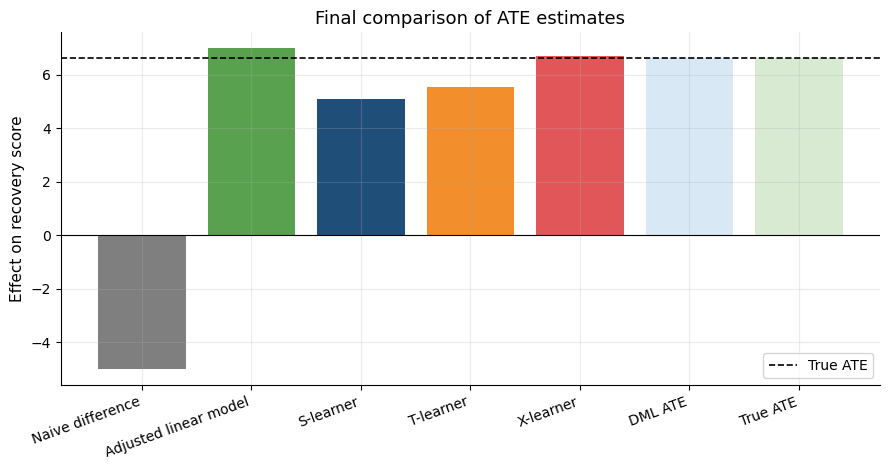

In [708]:
fig, ax = plt.subplots(figsize=(9, 4.8))

plot_colors = [
    COLORS["gray"],
    COLORS["green"],
    COLORS["navy"],
    COLORS["orange"],
    COLORS["red"],
    COLORS["light_blue"],
    COLORS["light_green"],
]

ax.bar(
    all_results["Method"],
    all_results["Estimated ATE"],
    color=plot_colors
)

ax.axhline(
    true_ate,
    color="black",
    linewidth=1.2,
    linestyle="--",
    label="True ATE"
)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Final comparison of ATE estimates")
ax.set_ylabel("Effect on recovery score")
ax.legend()

plt.xticks(rotation=20, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()

The figure gives a compact visual summary of the chapter.

The gray bar shows the naive difference. It is below zero, which would lead to the wrong conclusion if interpreted causally. This reinforces the central problem of confounding.

The green bar shows the adjusted linear model. It is close to the true ATE line, showing that adjustment can greatly improve the estimate when the adjustment set is appropriate.

The navy and orange bars show the S-learner and T-learner. They are positive but below the true ATE, indicating that they recover the beneficial direction of treatment but underestimate its magnitude.

The red bar shows the X-learner. It is close to the true ATE and performs well in this simulation.

The light blue bar shows DML. It is almost aligned with the true ATE line. In this example, DML gives the most accurate average-effect estimate.

The visual lesson is:

> The largest difference is not between advanced causal ML methods. The largest difference is between naive association and methods that use an explicit causal adjustment strategy.

---
### 11.3 What each method is useful for

The table below summarizes how to think about the methods introduced in this chapter.

| Method | Main target | Main strength | Main limitation | When it is useful |
|---|---|---|---|---|
| Naive difference | Observed association | Simple diagnostic baseline | Confounded when treatment is not random | As a warning or starting comparison |
| Adjusted linear model | ATE | Transparent and easy to explain | Sensitive to model misspecification | When relationships are approximately linear and adjustment set is clear |
| S-learner | ATE and CATE | Simple ML-based treatment-effect estimation | May shrink or smooth treatment effects | When a simple flexible baseline is needed |
| T-learner | ATE and CATE | Allows separate outcome surfaces | Sensitive to weak overlap and group imbalance | When treated and untreated groups both have enough data |
| X-learner | ATE and CATE | Good for heterogeneous effects and imbalance | More complex; depends on several models | When treatment effects vary and treatment groups are imbalanced |
| DML | ATE | Uses flexible ML while reducing nuisance-model bias | Mainly estimates average effects in this simple implementation | When the goal is a robust ATE with complex nuisance functions |
| Causal forest / EconML | CATE and ATE | Specialized HTE estimation | Requires package, diagnostics, and careful tuning | When heterogeneous effects are a primary goal |

No method removes the need for causal assumptions. Each method estimates a causal quantity only under a credible causal design.

---
### 11.4 How to interpret disagreement across methods

In real projects, different estimators often produce different results. This should not be treated as a nuisance; it is useful information.

Disagreement may arise because:

- the outcome model is misspecified,
- treatment assignment is difficult to model,
- overlap between treated and untreated units is weak,
- treatment effects are heterogeneous,
- regularization smooths treatment signals,
- important confounders are missing,
- one method extrapolates more than another.

A practical interpretation strategy is:

| Pattern across methods | Possible interpretation |
|---|---|
| Naive estimate differs strongly from adjusted methods | Confounding is likely important |
| Adjusted methods agree in sign and magnitude | Result may be more stable |
| ATE methods agree but CATE patterns differ | Average effect may be easier to estimate than heterogeneity |
| Meta-learners disagree strongly | Check overlap, subgroup size, and model sensitivity |
| DML differs strongly from outcome-model estimates | Nuisance modeling or treatment assignment may be influential |
| All methods are unstable | The data may not support a reliable causal estimate |

The purpose of method comparison is not to choose the estimate that looks most favorable. The purpose is to understand how sensitive the causal conclusion is to modeling choices.

---
### 11.5 Connecting the results to the healthcare example

In this simulated healthcare example, the main causal question was:

$$E[RecoveryScore \mid do(Treatment=1)] - E[RecoveryScore \mid do(Treatment=0)]$$

The true answer is positive: treatment improves recovery on average.

However, the naive observed comparison suggested the opposite. This happened because the treatment was assigned observationally. More severe patients were more likely to receive treatment, and more severe patients also tended to have lower recovery scores.

After adjustment, the estimated effects became positive and moved much closer to the true causal effect. This shows why the causal design matters.

The heterogeneous-effect analysis added a second layer of insight. The treatment was not equally beneficial for all patients. The true treatment effect increased with baseline severity. Therefore, the treatment was beneficial on average, but especially beneficial for more severe patients.

This is the practical value of causal machine learning:

- estimate whether an intervention works on average,
- estimate for whom it works more or less,
- distinguish predictive association from interventional effect,
- support decisions under explicit assumptions.

---
### 11.6 Main interpretation lesson

The results in this chapter can be summarized as follows.

| Question | Best-supported answer in the simulation |
|---|---|
| Does the treatment improve recovery on average? | Yes. The true ATE is positive, and adjusted causal ML methods recover a positive effect. |
| Is the naive comparison reliable? | No. It gives the wrong direction because treatment assignment is confounded. |
| Do all causal ML methods give the same estimate? | No. They differ because they use different modeling strategies. |
| Is heterogeneity important? | Yes. Treatment benefit increases with baseline severity. |
| Is the most complex method always best? | No. Method choice depends on the estimand, data structure, overlap, and assumptions. |
| Can ML replace causal assumptions? | No. ML helps estimation, but the causal design remains essential. |

The key message is:

> Causal machine learning is not a single algorithm. It is a workflow that combines causal assumptions, treatment-effect estimands, adjustment logic, flexible estimation, diagnostics, and interpretation.

This prepares us for the final part of the chapter: the practical checklist, chapter summary, and course project activity.

</br>

---
## 12. Practical Checklist for Causal ML Projects

Before applying causal machine learning to a real dataset, use the checklist below.

| Step | Key questions |
|---|---|
| Causal question | What is the treatment, intervention, exposure, or policy? What is the outcome? What decision or scientific question does the effect estimate support? |
| Estimand | Are you estimating ATE, ATT, ATU, CATE, or another quantity? Is the goal average effect estimation or subgroup-level targeting? |
| Adjustment set | Which variables are measured before treatment? Which variables are confounders? Are there post-treatment variables, mediators, colliders, or selection variables that should not be adjusted for? |
| Assumptions | Is consistency plausible? Is there no major unmeasured confounding? Is overlap/positivity plausible? Does the adjustment set block the relevant backdoor paths? |
| Method choice | Is a simple adjusted model sufficient, or is flexible ML needed? Is heterogeneity important? Are meta-learners, DML, or causal forests appropriate? |
| Validation | Are treated and untreated units comparable after adjustment? Are propensity scores overlapping? Are results stable across methods and model choices? Do the findings make domain sense? |
| Interpretation | Are results reported as causal estimates under assumptions, not as proof? Are limitations, uncertainty, and possible sources of bias clearly stated? |

The practical rule is:

> Start with the causal design, then choose the machine learning method.

A technically advanced model cannot fix a poorly defined treatment, an inappropriate adjustment set, missing confounders, or weak overlap.

</br>

---
## 13. Chapter Summary

This chapter introduced causal machine learning for treatment-effect estimation.

The main points are:

- Ordinary machine learning estimates predictive patterns such as $E[Y \mid X]$ or $E[Y \mid T, X]$.
- Causal effect estimation targets interventional and counterfactual quantities such as $E[Y \mid do(T=1)] - E[Y \mid do(T=0)]$.
- The fundamental problem of causal inference is that each unit has missing counterfactual outcomes.
- Potential outcomes provide the language for defining $Y(1)$, $Y(0)$, individual treatment effects, ATE, ATT, ATU, and CATE.
- Naive comparisons are generally biased in observational data when treatment assignment is confounded.
- Adjusted outcome modeling implements a simple form of backdoor-style standardization when the adjustment set is appropriate.
- S-, T-, and X-learners use supervised learning models to estimate average and heterogeneous treatment effects.
- CATE analysis helps answer not only whether a treatment works on average, but also for whom it works more or less.
- Double Machine Learning uses nuisance models, residualization, orthogonalization, and cross-fitting to estimate causal effects with flexible ML.
- EconML and related libraries provide practical implementations, but the causal design remains the responsibility of the analyst.
- Method comparison helps reveal whether conclusions are stable or sensitive to modeling choices.
- Causal ML results require careful interpretation, overlap checks, uncertainty analysis, robustness checks, and domain validation.

The central lesson is:

> Machine learning can help estimate causal effects, but it does not remove the need for causal assumptions.

Causal machine learning is therefore best understood as a workflow: define the causal question, choose the estimand, specify the adjustment strategy, select an estimator, validate the result, and interpret the estimate under explicit assumptions.


</br>

---
## Chapter Activity and Project Launch
### Method selection and assumptions report

**Length:** 1–2 pages.

For your final project, prepare a short report that addresses the following points.

1. **Causal question**
   - What is the treatment, intervention, exposure, or policy?
   - What is the outcome?
   - What causal quantity are you trying to estimate?

2. **Selected method**
   - Which method will you use?
   - Examples: adjusted outcome model, propensity weighting, S-learner, T-learner, X-learner, Double ML, causal forest, DoWhy, EconML, CausalML, DoubleML.

3. **Why this method fits your data**
   - Is the outcome continuous, binary, time-to-event, or another type?
   - Is the treatment binary, continuous, or multi-valued?
   - Is heterogeneity important?
   - Is the dataset high-dimensional or nonlinear?

4. **Required assumptions**
   - Which confounders must be measured?
   - Is overlap plausible?
   - Are there possible unmeasured confounders?
   - Are there post-treatment variables that should be excluded for total-effect estimation?

5. **Expected outputs and visualization**
   - Will you report ATE, ATT, CATE, or subgroup effects?
   - What plots will you include?
   - How will you interpret the result as a causal claim rather than only a prediction?

6. **Limitations**
   - What could bias your estimate?
   - What sensitivity or robustness checks are possible?

The report should prepare the methodological foundation for the final Google Colab project.


</br>

---
## References and further reading

- Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., and Robins, J. (2018). [Double/debiased machine learning for treatment and structural parameters](https://academic.oup.com/ectj/article/21/1/C1/5056401). *The Econometrics Journal*.  
- Künzel, S. R., Sekhon, J. S., Bickel, P. J., and Yu, B. (2019). [Metalearners for estimating heterogeneous treatment effects using machine learning](https://www.pnas.org/doi/10.1073/pnas.1804597116). *Proceedings of the National Academy of Sciences*.  
- Athey, S., and Imbens, G. (2016). [Recursive partitioning for heterogeneous causal effects](https://www.pnas.org/doi/10.1073/pnas.1510489113). *Proceedings of the National Academy of Sciences*.  
- Wager, S., and Athey, S. (2018). [Estimation and inference of heterogeneous treatment effects using random forests](https://doi.org/10.1080/01621459.2017.1319839). *Journal of the American Statistical Association*.  
- Athey, S., Tibshirani, J., and Wager, S. (2019). [Generalized random forests](https://projecteuclid.org/journals/annals-of-statistics/volume-47/issue-2/Generalized-random-forests/10.1214/18-AOS1709.full). *The Annals of Statistics*.  
- Battocchi, K., Dillon, E., Hei, M., Lewis, G., Oka, P., Oprescu, M., and Syrgkanis, V. (2019). [EconML: A Python package for ML-based heterogeneous treatment effects estimation](https://github.com/py-why/EconML). Software package and documentation.  
- Bach, P., Chernozhukov, V., Kurz, M. S., and Spindler, M. (2022). [DoubleML: An object-oriented implementation of Double Machine Learning in Python](https://www.jmlr.org/papers/v23/21-0862.html). *Journal of Machine Learning Research*.  
- Hernán, M. A., and Robins, J. M. (2020). [Causal Inference: What If](https://miguelhernan.org/whatifbook). Chapman & Hall/CRC.  
- Pearl, J. (2009). [Causality: Models, Reasoning, and Inference](https://www.cambridge.org/core/books/causality/B0046844FAE10CBF274D4ACBDAEB5F5B). Cambridge University Press.  
- Neal, B. (2020). [Introduction to Causal Inference from a Machine Learning Perspective](https://www.bradyneal.com/causal-inference-course). Course notes.